# WaveFusionNet: Brain Tumor MRI Classification
## Wavelet-Enhanced Dual-Path CNN-Transformer with Cross-Attention Feature Fusion

**Novel Contributions:**
1. **Dual-domain preprocessing** — spatial (CLAHE + skull strip) + frequency-domain (DWT wavelet enhancement)
2. **Dual-path feature extraction** — EfficientNetV2-S (local multi-scale) + DenseNet201 (dense feature reuse)
3. **CBAM attention** (Channel + Spatial) on each path before fusion
4. **Cross-Attention Feature Fusion Module (CAFM)** — learnable bidirectional multi-head attention between paths
5. **Tri-head ensemble classifier** — Softmax + SVM (RBF) + XGBoost with optimized voting weights
6. **Test-Time Augmentation (TTA)** + **Mixup training** for robust generalization

**Classes:** `glioma` · `meningioma` · `notumor` · `pituitary`

---

| Phase | Steps | Key Technique |
|-------|-------|---------------|
| **1 – Preprocessing** | CLAHE · Skull Strip · DWT | Wavelet edge enhancement (Novel) |
| **2 – Augmentation** | Geometric · Mixup · Class Weights | Advanced data expansion |
| **3 – Architecture** | EfficientNetV2-S · DenseNet201 · CBAM | Dual-path + attention |
| **4 – Fusion** | Cross-Attention · GAP | Bidirectional multi-head attention (Novel) |
| **5 – Classification** | Softmax · SVM · XGBoost | Weighted ensemble + TTA (Novel) |
| **6 – Evaluation** | CM · DSC · ROC · Grad-CAM | Comprehensive metrics |

In [1]:
# ============================================================
# FIX — XLA libdevice path (must run BEFORE importing TensorFlow)
# ============================================================
import os

os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/opt/conda"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

print("✅ XLA_FLAGS set → /opt/conda")
print("   libdevice found at: /opt/conda/nvvm/libdevice/libdevice.10.bc")

✅ XLA_FLAGS set → /opt/conda
   libdevice found at: /opt/conda/nvvm/libdevice/libdevice.10.bc


In [3]:
# ============================================================
# STEP 0 — PACKAGE INSTALLATION
# ============================================================
import subprocess, sys

required = [
    "tensorflow>=2.15.0",  # A10G (CUDA 12) — ml.g5.2xlarge
    "opencv-python-headless",
    "scikit-learn>=1.1",
    "imbalanced-learn",
    "matplotlib",
    "seaborn",
    "scikit-image",
    "Pillow",
    "tqdm",
    "numpy",
    "pandas",
    "scipy",
    "albumentations",
    "PyWavelets",
    "xgboost",
    "boto3",
    "h5py",
]

for pkg in required:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed successfully!")
print("RESTART the kernel now if this is your first run, then continue.")


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
amazon-sagemaker-jupyter-ai-q-developer 1.2.9 requires numpy<=2.0.1, but you have numpy 2.4.4 which is incompatible.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.4.4 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.4 which is incompatible.
autogluon-core 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.4 which is incompatible.
autogluon-features 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have 

All packages installed successfully!
RESTART the kernel now if this is your first run, then continue.


In [4]:
# ============================================================
# STEP 1b — DOWNLOAD & EXTRACT DATASET FROM S3 (AWS SageMaker)
# ============================================================
import subprocess, os, zipfile, glob

S3_BUCKET   = "braintumordatatset"          # <-- your bucket name
S3_PREFIX   = ""                            # <-- sub-folder prefix (empty = bucket root)
SAGEMAKER   = "/home/sagemaker-user"
DOWNLOAD_DIR = os.path.join(SAGEMAKER, "dataset2")   # raw download landing zone
EXTRACT_DIR  = os.path.join(SAGEMAKER, "dataset2")   # final extracted dataset root

os.makedirs(DOWNLOAD_DIR, exist_ok=True)

# ── Step A: Sync from S3 ─────────────────────────────────────
s3_uri = f"s3://{S3_BUCKET}/{S3_PREFIX}".rstrip("/")
print(f"Syncing  {s3_uri}  →  {DOWNLOAD_DIR} ...")
result = subprocess.run(
    ["aws", "s3", "sync", s3_uri, DOWNLOAD_DIR, "--region", "eu-north-1"],
    capture_output=True, text=True
)
if result.stdout:
    print(result.stdout[-2000:])
if result.returncode != 0:
    print("STDERR:", result.stderr[-1000:])
    raise RuntimeError("S3 sync failed — check bucket name and IAM role permissions.")
print("S3 sync complete.")

# ── Step B: Unzip any .zip files found ───────────────────────
zip_files = glob.glob(os.path.join(DOWNLOAD_DIR, "**/*.zip"), recursive=True) + \
            glob.glob(os.path.join(DOWNLOAD_DIR, "*.zip"))

if zip_files:
    for zf in zip_files:
        print(f"\nExtracting {os.path.basename(zf)} ...")
        with zipfile.ZipFile(zf, 'r') as z:
            # Detect whether zip wraps a single top-level folder
            top_dirs = {p.split('/')[0] for p in z.namelist() if p.strip('/')}
            if len(top_dirs) == 1:
                top = top_dirs.pop()
                # Extract alongside the zip; then point EXTRACT_DIR at that sub-folder
                z.extractall(SAGEMAKER)
                extracted_top = os.path.join(SAGEMAKER, top)
                print(f"  Extracted to: {extracted_top}")
                # If extracted folder name differs from EXTRACT_DIR, update global path
                if extracted_top != EXTRACT_DIR:
                    EXTRACT_DIR = extracted_top
            else:
                z.extractall(DOWNLOAD_DIR)
                print(f"  Extracted to: {DOWNLOAD_DIR}")
        print(f"  Done extracting {os.path.basename(zf)}")
else:
    print("No zip files found — assuming dataset is already extracted.")

# ── Step C: Auto-detect the actual dataset root ───────────────
# Walk up to 2 levels to find the folder containing Training/ and Testing/
def find_dataset_root(base, max_depth=3):
    for root, dirs, _ in os.walk(base):
        depth = root.replace(base, '').count(os.sep)
        if depth > max_depth:
            continue
        if 'Training' in dirs and 'Testing' in dirs:
            return root
    return None

detected = find_dataset_root(SAGEMAKER)
if detected:
    EXTRACT_DIR = detected
    print(f"\nDataset root detected: {EXTRACT_DIR}")
else:
    print(f"\nWARNING: Could not auto-detect Training/Testing folders under {SAGEMAKER}")
    print("Please set EXTRACT_DIR manually in the Config cell below.")

# ── Step D: Print structure ───────────────────────────────────
print("\nDirectory structure:")
for root, dirs, files in os.walk(EXTRACT_DIR if detected else SAGEMAKER):
    depth = root.replace(SAGEMAKER, '').count(os.sep)
    if depth > 3: continue
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")

print(f"\n✓ Use this path in Config below:  DATASET_ROOT = \"{EXTRACT_DIR if detected else '???'}\"")


Syncing  s3://braintumordatatset  →  /home/sagemaker-user/dataset2 ...
S3 sync complete.

Extracting dataset2.zip ...
  Extracted to: /home/sagemaker-user/dataset2
  Done extracting dataset2.zip

Extracting dataset2.zip ...
  Extracted to: /home/sagemaker-user/dataset2
  Done extracting dataset2.zip

Dataset root detected: /home/sagemaker-user/dataset2

Directory structure:
  dataset2/  (1 files)
    Testing/  (0 files)
      glioma_tumor/  (1024 files)
      meningioma_tumor/  (1061 files)
      no_tumor/  (1205 files)
      pituitary_tumor/  (2457 files)
    Training/  (0 files)
      glioma_tumor/  (3697 files)
      meningioma_tumor/  (3857 files)
      no_tumor/  (3595 files)
      pituitary_tumor/  (3861 files)

✓ Use this path in Config below:  DATASET_ROOT = "/home/sagemaker-user/dataset2"


In [4]:
# ============================================================
# SECTION 1 — IMPORT ALL REQUIRED LIBRARIES
# ============================================================
import os, sys, warnings, random, time, json, pickle, gc
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm
import scipy.ndimage as ndimage
import pywt  # PyWavelets for Discrete Wavelet Transform

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2S, DenseNet201

# Machine Learning
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, auc
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from skimage.filters import threshold_otsu

import xgboost as xgb

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

# ── A10G GPU setup (ml.g5.2xlarge) ──────────────────────────────
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# A10G Tensor Cores require mixed_float16 — do NOT remove this.
# This halves VRAM usage and activates hardware acceleration.
tf.keras.mixed_precision.set_global_policy("mixed_float16")

# Enable XLA JIT compilation — A10G benefits significantly
tf.config.optimizer.set_jit(True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"TensorFlow {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")
for g in tf.config.list_physical_devices("GPU"):
    print(f"   {g}")
print(f"Mixed precision policy: {tf.keras.mixed_precision.global_policy().name}")


2026-05-07 02:51:06.509662: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778122266.525080    1148 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778122266.529912    1148 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow 2.18.0
GPU available: True
   PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Mixed precision policy: mixed_float16


In [6]:
# ============================================================
# GPU HEALTH CHECK (ml.g5.2xlarge — A10G) — run this before anything else
# ============================================================
import subprocess, tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow : {tf.__version__}")
print(f"GPUs found : {len(gpus)}")
for g in gpus:
    print(f"  {g}")

# nvidia-smi — confirms A10G is visible
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0
      else 'nvidia-smi not available (CPU instance?)')

# Mixed precision check
policy = tf.keras.mixed_precision.global_policy()
print(f"Mixed precision policy : {policy.name}")
print(f"XLA JIT enabled        : {tf.config.optimizer.get_jit()}")

if not gpus:
    print("\n⚠ WARNING: No GPU detected!")
    print("  → Make sure you selected a GPU image (TensorFlow 2.x GPU)")
    print("  → Restart the Space after changing the image type")
else:
    print("\n✓ A10G ready — proceed with training")


TensorFlow : 2.18.0
GPUs found : 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Tue May  5 02:10:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A10G                    On  |   00000000:00:1E.0 Off |                    0 |
|  0%   31C    P0             57W /  300W |       3MiB /  23028MiB |      0%      Default |
|                                     

In [7]:
# ============================================================
# GLOBAL CONFIGURATION
# ============================================================
class Config:
    # Dataset layout
    DATASET_ROOT = "/home/sagemaker-user/dataset2"
    TRAIN_DIR    = os.path.join(DATASET_ROOT, "Training")
    TEST_DIR     = os.path.join(DATASET_ROOT, "Testing")
    OUTPUT_DIR   = "/home/sagemaker-user/outputs_wavefusionnet"

    # Image parameters
    IMG_SIZE     = (224, 224)
    INPUT_SHAPE  = (224, 224, 3)

    # Class labels
    CLASS_NAMES  = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]
    NUM_CLASSES  = 4

    # Preprocessing
    CLAHE_CLIP   = 2.0
    CLAHE_TILE   = (8, 8)
    CROP_BRAIN   = True        # Crop to brain region (remove black borders)
    WAVELET      = "db2"       # Daubechies-2 wavelet
    WAVELET_LVL  = 2           # Decomposition levels
    EDGE_BOOST   = 1.0         # 1.0 = denoise only (no artificial edge amplification)

    # Training
    BATCH_SIZE   = 64          # A10G 24 GB — 64 fits well; try 96 if no OOM
    EPOCHS_P1    = 30          # Phase 1: frozen backbones (A10G ~6 min total)
    EPOCHS_P2    = 60          # Phase 2: fine-tuning   (A10G ~15 min total)
    LR_P1        = 1e-3
    LR_P2        = 5e-5
    LABEL_SMOOTH = 0.1
    VAL_SPLIT    = 0.2
    MIXUP_ALPHA  = 0.2

    # Architecture
    EMBED_DIM    = 256
    NUM_HEADS    = 4
    DROPOUT      = 0.5

    # Ensemble
    TTA_AUGMENTS = 10

cfg = Config()
for d in ["models", "plots", "features"]:
    os.makedirs(os.path.join(cfg.OUTPUT_DIR, d), exist_ok=True)

COLORS = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

print(f"Config ready")
print(f"  Dataset  : {cfg.DATASET_ROOT}")
print(f"  Output   : {cfg.OUTPUT_DIR}")
print(f"  Image    : {cfg.IMG_SIZE} | Classes: {cfg.CLASS_NAMES}")


Config ready
  Dataset  : /home/sagemaker-user/dataset2
  Output   : /home/sagemaker-user/outputs_wavefusionnet
  Image    : (224, 224) | Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


---
## Phase 1 — Data Preparation & Preprocessing

### Step 1.1 — Data Scanning & Format Standardization
### Step 1.2 — CLAHE Contrast Enhancement + Otsu Skull Stripping
### Step 1.3 — Discrete Wavelet Transform (DWT) Enhancement (Novel)

**Novelty:** DWT decomposes each MRI into frequency sub-bands:
- **LL** (approximation): low-frequency structural information
- **LH, HL** (details): horizontal and vertical edge information
- **HH** (diagonal): diagonal texture patterns

Detail sub-bands are soft-thresholded (denoised) then amplified by a boost factor,
enhancing tumor boundary contrast while suppressing noise. The inverse DWT reconstructs
a wavelet-enhanced image that combines the best of both spatial and frequency domains.

Training images : 15010
Testing  images : 5747

Class distribution — Training:
label
pituitary_tumor     3861
meningioma_tumor    3857
glioma_tumor        3697
no_tumor            3595


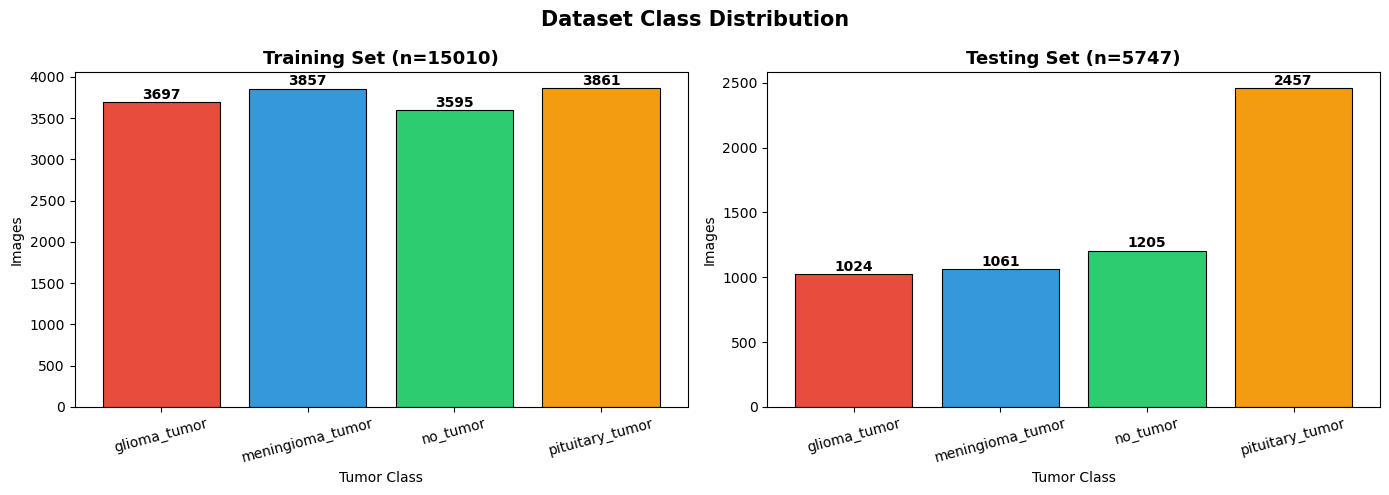

Step 1.1 complete


In [8]:
# ============================================================
# SECTION 2 — DATA SCANNING & DISTRIBUTION
# ============================================================
SUPPORTED_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif"}

def scan_dataset(root_dir, class_names):
    records = []
    for cls in class_names:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            print(f"  Warning: {cls_dir} not found")
            continue
        for f in Path(cls_dir).rglob("*"):
            if f.suffix.lower() in SUPPORTED_EXT:
                records.append({"filepath": str(f), "label": cls,
                               "label_idx": class_names.index(cls)})
    return pd.DataFrame(records)

df_train = scan_dataset(cfg.TRAIN_DIR, cfg.CLASS_NAMES)
df_test  = scan_dataset(cfg.TEST_DIR,  cfg.CLASS_NAMES)

print(f"Training images : {len(df_train)}")
print(f"Testing  images : {len(df_test)}")
print(f"\nClass distribution — Training:\n{df_train['label'].value_counts().to_string()}")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df, title) in zip(axes, [(df_train, "Training"), (df_test, "Testing")]):
    counts = df["label"].value_counts().reindex(cfg.CLASS_NAMES, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=COLORS, edgecolor="black", lw=0.8)
    ax.set_title(f"{title} Set (n={len(df)})", fontsize=13, fontweight="bold")
    ax.set_xlabel("Tumor Class"); ax.set_ylabel("Images")
    ax.tick_params(axis="x", rotation=15)
    for b, v in zip(bars, counts.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+3,
                str(v), ha="center", va="bottom", fontweight="bold")
plt.suptitle("Dataset Class Distribution", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "plots", "class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Step 1.1 complete")

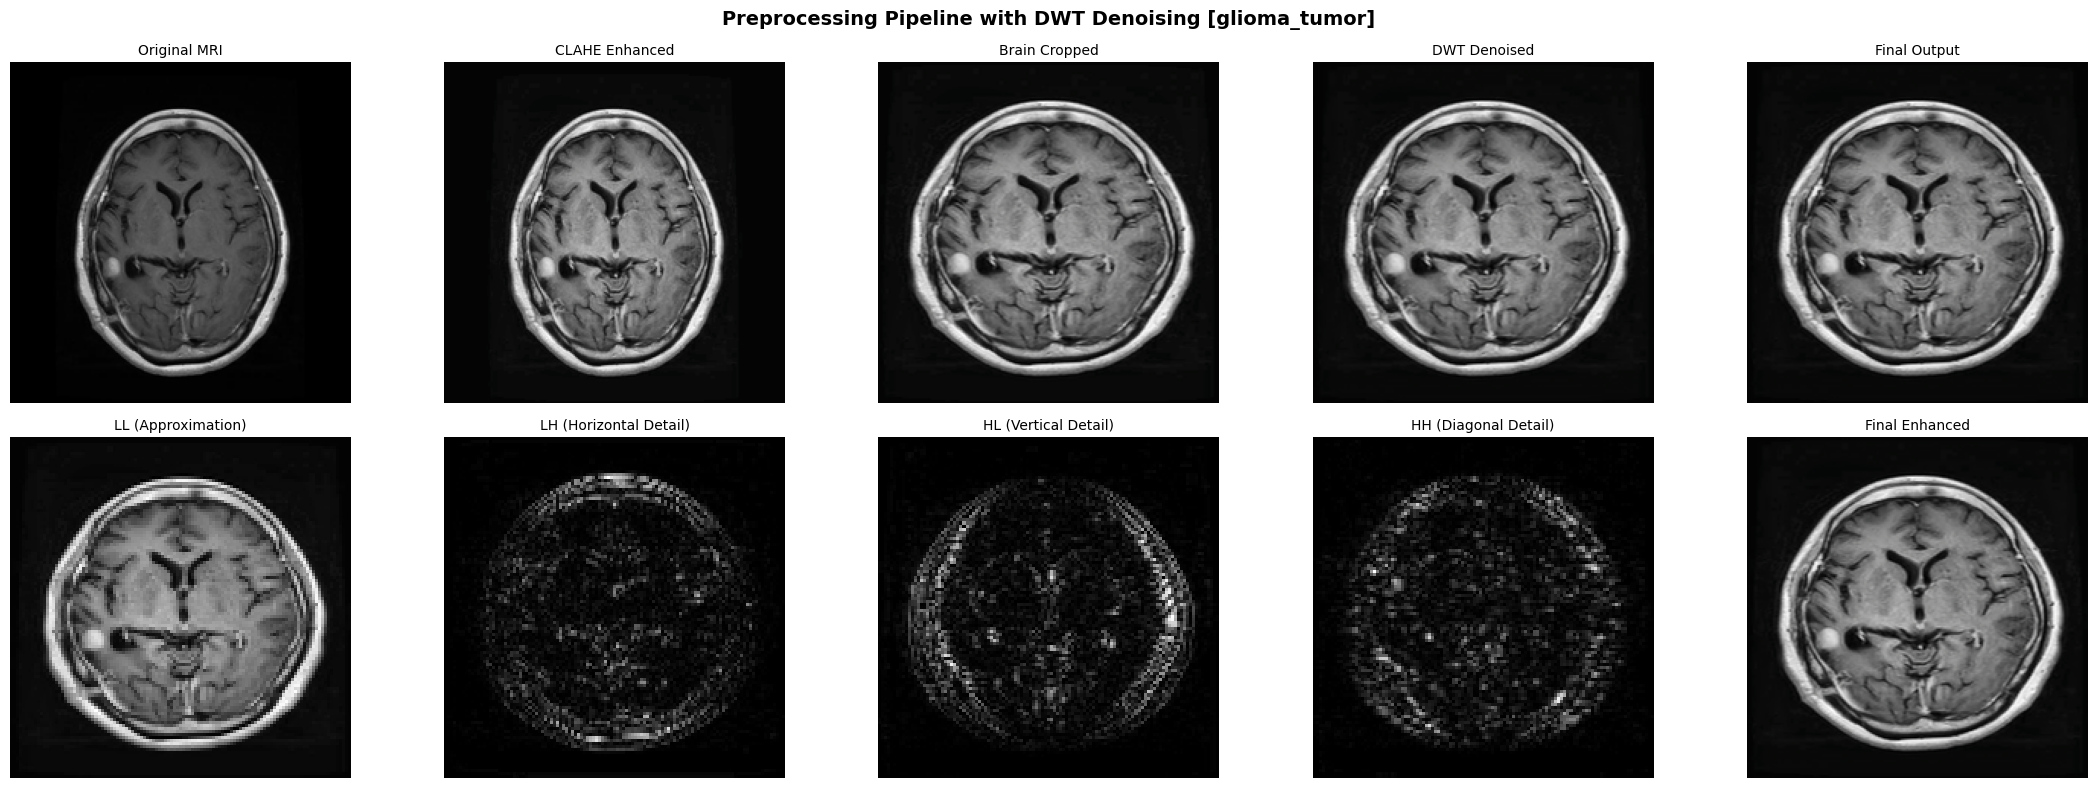

Preprocessing with brain cropping + DWT denoising ready


In [9]:
# ============================================================
# SECTION 3 — PREPROCESSING: CLAHE + BRAIN CROP + DWT
# ============================================================

def apply_clahe(image, clip=2.0, tile=(8, 8)):
    """CLAHE on the L channel of LAB colour space."""
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
    if image.ndim == 3:
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return clahe.apply(image)


def crop_brain_region(image, pad_pct=0.02):
    """
    Crop to brain bounding box — removes only black background.
    Unlike skull stripping, this preserves ALL brain and tumor tissue.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if image.ndim == 3 else image.copy()
    _, binary = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    coords = cv2.findNonZero(binary)
    if coords is None:
        return image

    x, y, w, h = cv2.boundingRect(coords)

    # Add small padding
    pad_x = int(w * pad_pct)
    pad_y = int(h * pad_pct)
    x = max(0, x - pad_x)
    y = max(0, y - pad_y)
    w = min(image.shape[1] - x, w + 2 * pad_x)
    h = min(image.shape[0] - y, h + 2 * pad_y)

    cropped = image[y:y+h, x:x+w]
    return cv2.resize(cropped, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_LANCZOS4)


def wavelet_enhance(image, wavelet="db2", level=2, edge_boost=1.0):
    """
    DWT-based denoising for MRI brain tumor images.
    With edge_boost=1.0: pure denoising (no artificial edge amplification).
    """
    enhanced_channels = []
    n_channels = image.shape[2] if image.ndim == 3 else 1

    for c in range(n_channels):
        channel = (image[:, :, c] if image.ndim == 3 else image).astype(np.float64)
        coeffs = pywt.wavedec2(channel, wavelet, level=level)
        sigma = np.median(np.abs(coeffs[-1][-1])) / 0.6745
        threshold = sigma * 0.5

        for i in range(1, len(coeffs)):
            coeffs[i] = tuple(
                pywt.threshold(d, threshold, mode="soft") * edge_boost
                for d in coeffs[i]
            )

        recon = pywt.waverec2(coeffs, wavelet)
        recon = recon[:image.shape[0], :image.shape[1]]
        enhanced_channels.append(np.clip(recon, 0, 255))

    if image.ndim == 3:
        return np.stack(enhanced_channels, axis=-1).astype(np.uint8)
    return np.clip(enhanced_channels[0], 0, 255).astype(np.uint8)


def preprocess_image(path):
    """Full pipeline: Load -> CLAHE -> Brain Crop -> DWT Denoise -> Normalize [0,1]."""
    try:
        img = Image.open(path).convert("RGB").resize(cfg.IMG_SIZE, Image.LANCZOS)
        img = np.array(img)
    except Exception:
        return None
    img = apply_clahe(img, cfg.CLAHE_CLIP, cfg.CLAHE_TILE)
    if cfg.CROP_BRAIN:
        img = crop_brain_region(img)
    img = wavelet_enhance(img, cfg.WAVELET, cfg.WAVELET_LVL, cfg.EDGE_BOOST)
    return img.astype(np.float32) / 255.0


# ── Visualize preprocessing pipeline ─────────────────────────
sample_row = df_train.sample(1, random_state=SEED).iloc[0]
raw = np.array(Image.open(sample_row["filepath"]).convert("RGB").resize(cfg.IMG_SIZE, Image.LANCZOS))
clahe_img = apply_clahe(raw, cfg.CLAHE_CLIP, cfg.CLAHE_TILE)
cropped = crop_brain_region(clahe_img)
wavelet_img = wavelet_enhance(cropped, cfg.WAVELET, cfg.WAVELET_LVL, cfg.EDGE_BOOST)

# DWT sub-band visualization
gray_cropped = cv2.cvtColor(cropped, cv2.COLOR_RGB2GRAY).astype(np.float64)
coeffs_vis = pywt.dwt2(gray_cropped, cfg.WAVELET)
LL, (LH, HL, HH) = coeffs_vis

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
# Row 1: preprocessing pipeline
for ax, img, t in zip(axes[0], [raw, clahe_img, cropped, wavelet_img, wavelet_img],
    ["Original MRI", "CLAHE Enhanced", "Brain Cropped", "DWT Denoised", "Final Output"]):
    ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
    ax.set_title(t, fontsize=10); ax.axis("off")

# Row 2: DWT sub-bands
for ax, sub, t in zip(axes[1], [LL, LH, HL, HH],
    ["LL (Approximation)", "LH (Horizontal Detail)", "HL (Vertical Detail)", "HH (Diagonal Detail)"]):
    ax.imshow(np.abs(sub), cmap="gray")
    ax.set_title(t, fontsize=10); ax.axis("off")
axes[1, 4].imshow(wavelet_img)
axes[1, 4].set_title("Final Enhanced", fontsize=10); axes[1, 4].axis("off")

plt.suptitle(f"Preprocessing Pipeline with DWT Denoising [{sample_row['label']}]",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "plots", "preprocessing_pipeline.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Preprocessing with brain cropping + DWT denoising ready")

In [10]:
# ============================================================
# SECTION 4 - MEMORY-SAFE PREPROCESSING (CHUNK -> HDF5)
# ============================================================
# Strategy (AWS SageMaker / EBS):
#   1. Process in 500-image chunks -> one .h5 per chunk on EBS
#      (crash-safe: resume skips finished chunks)
#   2. Merge chunks -> one HDF5 stored as uint8 (~2 GB vs 9 GB float32)
#   3. No copy needed: EBS reads are fast (replaces Colab /content/ SSD step)
#   4. Val + test loaded into RAM (~3 GB total); training reads per-batch from EBS
# ============================================================
import h5py, shutil

CHUNK_DIR   = os.path.join(cfg.OUTPUT_DIR, 'features', 'chunks')
TRAIN_HDF5  = os.path.join(cfg.OUTPUT_DIR, 'features', 'train_preprocessed.h5')
TEST_HDF5   = os.path.join(cfg.OUTPUT_DIR, 'features', 'test_preprocessed.h5')
# On SageMaker EBS, reads are already fast — no copy to /content/ needed.
LOCAL_TRAIN = TRAIN_HDF5   # same as merged HDF5 (EBS is fast)
LOCAL_TEST  = TEST_HDF5    # same as merged HDF5
CHUNK_SIZE  = 1000  # A10G instance has 32 GB RAM — larger chunks = faster

os.makedirs(CHUNK_DIR, exist_ok=True)


def preprocess_to_uint8(path):
    try:
        img = Image.open(path).convert('RGB').resize(cfg.IMG_SIZE, Image.LANCZOS)
        img = np.array(img)
    except Exception:
        return None
    img = apply_clahe(img, cfg.CLAHE_CLIP, cfg.CLAHE_TILE)
    if cfg.CROP_BRAIN:
        img = crop_brain_region(img)
    img = wavelet_enhance(img, cfg.WAVELET, cfg.WAVELET_LVL, cfg.EDGE_BOOST)
    return img.astype(np.uint8)   # store raw; divide /255 in generator


def preprocess_df_to_chunks(df, prefix, chunk_size=CHUNK_SIZE):
    n = len(df)
    for chunk_num, start in enumerate(range(0, n, chunk_size)):
        chunk_path = os.path.join(CHUNK_DIR, f'{prefix}_chunk_{chunk_num:04d}.h5')
        if os.path.exists(chunk_path):
            print(f'  chunk {chunk_num:04d} exists - skip')
            continue
        chunk = df.iloc[start:start + chunk_size]
        imgs, lbls = [], []
        for _, row in tqdm(chunk.iterrows(), total=len(chunk),
                           desc=f'{prefix} chunk {chunk_num:04d}'):
            img = preprocess_to_uint8(row['filepath'])
            if img is not None:
                imgs.append(img)
                lbls.append(row['label_idx'])
        if imgs:
            with h5py.File(chunk_path, 'w') as hf:
                hf.create_dataset('images', data=np.array(imgs, dtype=np.uint8),
                                  chunks=(1, cfg.IMG_SIZE[0], cfg.IMG_SIZE[1], 3))
                hf.create_dataset('labels', data=np.array(lbls, dtype=np.int32))
            print(f'  Saved chunk {chunk_num:04d} - {len(imgs)} images')
        del imgs, lbls
        gc.collect()


def merge_chunks(prefix, merged_path):
    if os.path.exists(merged_path):
        print(f'Merged file exists: {merged_path}')
        return
    chunk_files = sorted(
        os.path.join(CHUNK_DIR, x)
        for x in os.listdir(CHUNK_DIR)
        if x.startswith(f'{prefix}_chunk_') and x.endswith('.h5')
    )
    print(f'Merging {len(chunk_files)} chunks -> {merged_path}')
    img_shape = (cfg.IMG_SIZE[0], cfg.IMG_SIZE[1], 3)
    with h5py.File(merged_path, 'w') as out:
        imgs_ds = out.create_dataset('images',
            shape=(0,) + img_shape, maxshape=(None,) + img_shape,
            dtype='uint8', chunks=(1,) + img_shape)
        lbl_ds = out.create_dataset('labels',
            shape=(0,), maxshape=(None,), dtype='int32')
        offset = 0
        for cf in tqdm(chunk_files, desc='Merging'):
            with h5py.File(cf, 'r') as hf:
                ci = hf['images'][:]
                cl = hf['labels'][:]
            n = len(cl)
            imgs_ds.resize(offset + n, axis=0)
            lbl_ds.resize(offset + n, axis=0)
            imgs_ds[offset:offset + n] = ci
            lbl_ds[offset:offset + n]  = cl
            offset += n
            del ci, cl; gc.collect()
    print(f'Merged {offset} images')


def ensure_local(drive_path, local_path):
    if os.path.exists(local_path):
        print(f'Local copy exists: {local_path}')
        return
    print(f'Copying {os.path.basename(drive_path)} to local SSD...')
    shutil.copy(drive_path, local_path)
    print(f'  Done - {os.path.getsize(local_path)/1e9:.2f} GB')


# Step 1: Chunk-preprocess to Drive (crash-safe)
print('Step 1: Chunk-preprocessing training images...')
preprocess_df_to_chunks(df_train, 'train')

print('\nStep 1b: Chunk-preprocessing test images...')
preprocess_df_to_chunks(df_test, 'test')

# Step 2: Merge chunks
print('\nStep 2: Merging chunks...')
merge_chunks('train', TRAIN_HDF5)
merge_chunks('test',  TEST_HDF5)

# Step 3: Skipped on SageMaker (LOCAL_TRAIN/TEST already point to merged HDF5)
print('\nStep 3: Skipped — EBS path used directly (no copy needed on SageMaker)')

# Step 4: Build split indices + load val/test into RAM
with h5py.File(LOCAL_TRAIN, 'r') as hf:
    n_train_total    = len(hf['labels'])
    all_train_labels = hf['labels'][:]

train_idx, val_idx = train_test_split(
    np.arange(n_train_total),
    test_size=cfg.VAL_SPLIT,
    random_state=SEED,
    stratify=all_train_labels,
)
y_train = all_train_labels[train_idx]

sorted_val = np.sort(val_idx)
with h5py.File(LOCAL_TRAIN, 'r') as hf:
    X_val = hf['images'][list(sorted_val)].astype(np.float32) / 255.0
    y_val = hf['labels'][list(sorted_val)]

with h5py.File(LOCAL_TEST, 'r') as hf:
    X_test = hf['images'][:].astype(np.float32) / 255.0
    y_test = hf['labels'][:]

print(f'\nDataset ready:')
print(f'  Train idx : {len(train_idx)}  Val : {X_val.shape}  Test : {X_test.shape}')
print(f'  Val+Test RAM : {(X_val.nbytes + X_test.nbytes)/1e9:.1f} GB')
gc.collect()


Step 1: Chunk-preprocessing training images...
  chunk 0000 exists - skip
  chunk 0001 exists - skip
  chunk 0002 exists - skip
  chunk 0003 exists - skip
  chunk 0004 exists - skip
  chunk 0005 exists - skip
  chunk 0006 exists - skip
  chunk 0007 exists - skip
  chunk 0008 exists - skip
  chunk 0009 exists - skip
  chunk 0010 exists - skip
  chunk 0011 exists - skip
  chunk 0012 exists - skip
  chunk 0013 exists - skip
  chunk 0014 exists - skip
  chunk 0015 exists - skip

Step 1b: Chunk-preprocessing test images...
  chunk 0000 exists - skip
  chunk 0001 exists - skip
  chunk 0002 exists - skip
  chunk 0003 exists - skip
  chunk 0004 exists - skip
  chunk 0005 exists - skip

Step 2: Merging chunks...
Merged file exists: /home/sagemaker-user/outputs_wavefusionnet/features/train_preprocessed.h5
Merged file exists: /home/sagemaker-user/outputs_wavefusionnet/features/test_preprocessed.h5

Step 3: Skipped — EBS path used directly (no copy needed on SageMaker)

Dataset ready:
  Train idx 

12

---
## Phase 2 — Data Augmentation & Class Balancing

### Step 2.1 — Geometric Augmentation + Mixup (Novel enhancement)
**Mixup** blends pairs of training images and their labels with a random ratio,
creating soft decision boundaries and reducing overconfidence.

### Step 2.2 — Class-Weighted Loss
Instead of SMOTE (which creates blurry synthetic pixels), we use `compute_class_weight`
to rebalance the loss function — giving more weight to under-represented classes.

Class weights: {0: 1.0152181264795401, 1: 0.9727802981205443, 2: 1.0438108484005564, 3: 0.9718355454839754}


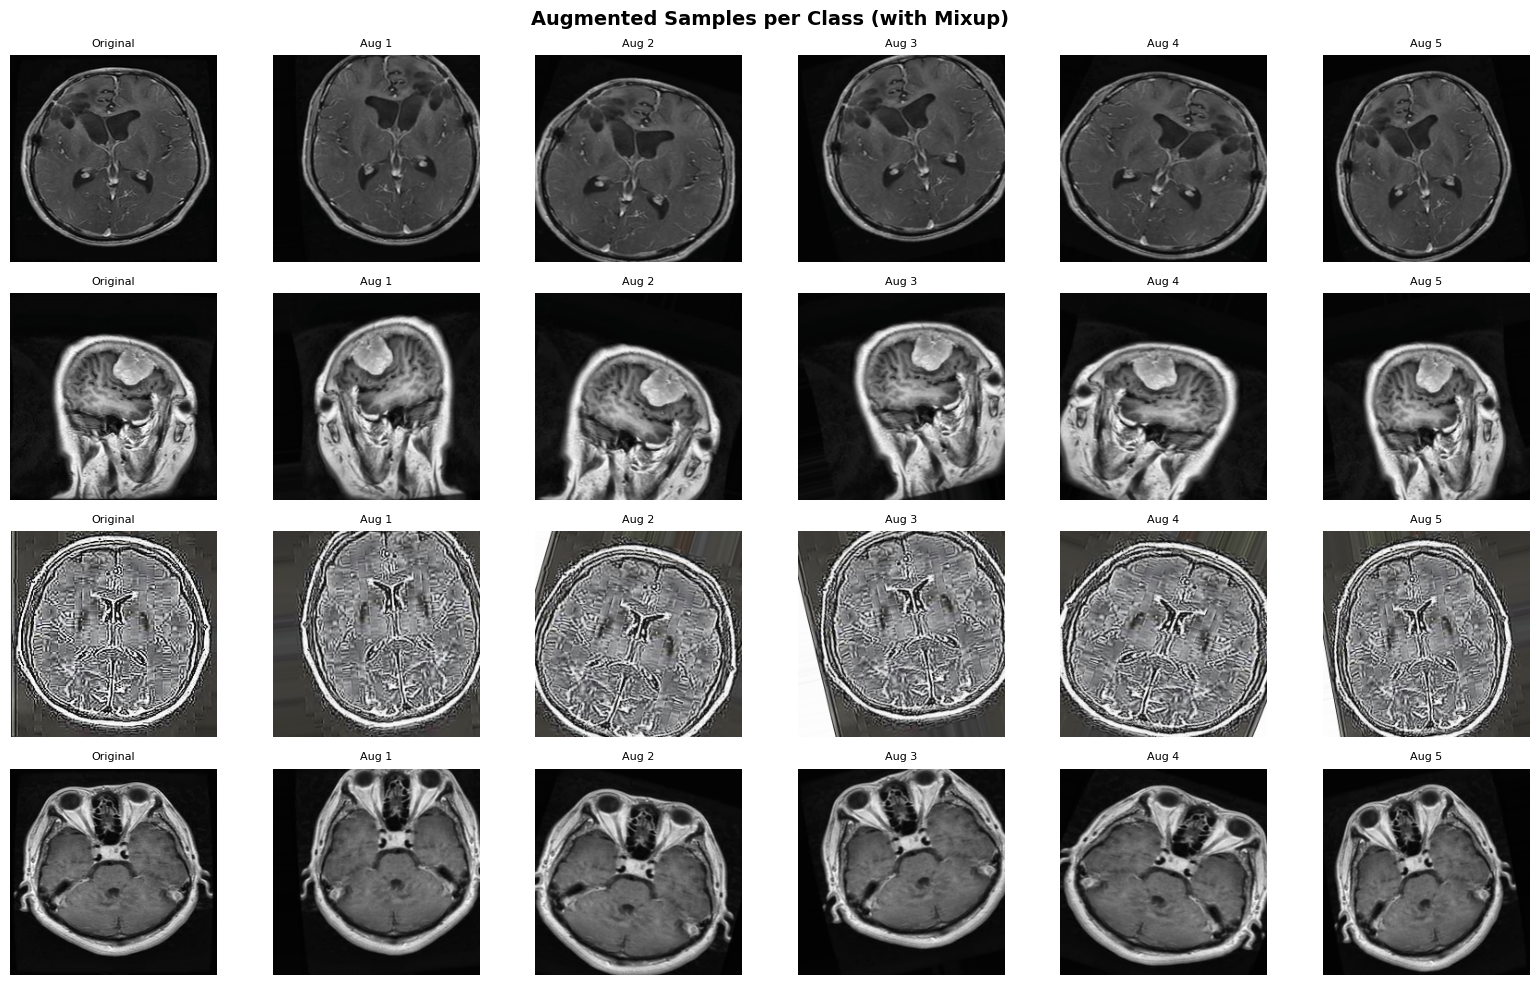

Training generator: 187 batches/epoch, batch_size=64
Phase 2 complete - HDF5MixupGenerator ready (vertical_flip disabled)


In [11]:
# ============================================================
# SECTION 5 - AUGMENTATION: GEOMETRIC + MIXUP + CLASS WEIGHTS
# ============================================================

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
)

cw_values = compute_class_weight('balanced', classes=np.arange(cfg.NUM_CLASSES), y=y_train)
class_weights = {i: float(w) for i, w in enumerate(cw_values)}
print(f'Class weights: {class_weights}')


def mixup_batch(x, y, alpha=0.2):
    batch_size = len(x)
    lam = np.random.beta(alpha, alpha, size=batch_size)
    lam = np.maximum(lam, 1 - lam)
    idx = np.random.permutation(batch_size)
    lam_img = lam.reshape(-1, 1, 1, 1)
    lam_lbl = lam.reshape(-1, 1)
    x_mixed = (lam_img * x + (1 - lam_img) * x[idx]).astype(np.float32)
    y_mixed = (lam_lbl * y + (1 - lam_lbl) * y[idx]).astype(np.float32)
    return x_mixed, y_mixed


class HDF5MixupGenerator(keras.utils.Sequence):
    """Reads batches from local SSD HDF5 (uint8) - only 1 batch in RAM at a time.
    IMPORTANT: use workers=1, use_multiprocessing=False in model.fit."""

    def __init__(self, hdf5_path, indices, batch_size, datagen, num_classes, mixup_alpha=0.2):
        self.hdf5_path   = hdf5_path
        self.indices     = np.array(indices)
        self.batch_size  = batch_size
        self.datagen     = datagen
        self.num_classes = num_classes
        self.mixup_alpha = mixup_alpha

    def __len__(self):
        return max(1, len(self.indices) // self.batch_size)

    def __getitem__(self, idx):
        batch_raw  = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        sorted_pos = np.argsort(batch_raw)
        sorted_idx = batch_raw[sorted_pos]   # h5py needs sorted for fast reads

        with h5py.File(self.hdf5_path, 'r') as hf:
            bx_u8  = hf['images'][list(sorted_idx)]
            by_raw = hf['labels'][list(sorted_idx)]

        inv = np.argsort(sorted_pos)
        bx  = bx_u8[inv].astype(np.float32) / 255.0   # uint8 -> [0,1] float32
        by  = keras.utils.to_categorical(by_raw[inv], self.num_classes)

        for i in range(len(bx)):
            bx[i] = self.datagen.random_transform(bx[i])

        if np.random.random() < 0.5:
            bx, by = mixup_batch(bx, by, self.mixup_alpha)

        return bx, by

    def on_epoch_end(self):
        np.random.shuffle(self.indices)


train_gen = HDF5MixupGenerator(
    LOCAL_TRAIN, train_idx, cfg.BATCH_SIZE,
    train_datagen, cfg.NUM_CLASSES, cfg.MIXUP_ALPHA
)

# Visualize augmented samples (load first 2000 train images for display)
fig, axes = plt.subplots(cfg.NUM_CLASSES, 6, figsize=(16, 10))
fig.suptitle('Augmented Samples per Class (with Mixup)', fontsize=14, fontweight='bold')
vis_idx = np.sort(train_idx[:2000])
with h5py.File(LOCAL_TRAIN, 'r') as hf:
    vis_imgs   = hf['images'][list(vis_idx)].astype(np.float32) / 255.0
    vis_labels = hf['labels'][list(vis_idx)]

for row_idx, cls in enumerate(cfg.CLASS_NAMES):
    cls_mask = (vis_labels == cfg.CLASS_NAMES.index(cls))
    cls_imgs = vis_imgs[cls_mask]
    if len(cls_imgs) == 0:
        continue
    seed_img = cls_imgs[0:1]
    gen = train_datagen.flow(seed_img, batch_size=1, seed=SEED)
    axes[row_idx, 0].imshow(seed_img[0])
    axes[row_idx, 0].set_title('Original', fontsize=8)
    axes[row_idx, 0].set_ylabel(cls, fontsize=9, rotation=0, labelpad=45)
    axes[row_idx, 0].axis('off')
    for col_idx in range(1, 6):
        aug = next(gen)[0]
        axes[row_idx, col_idx].imshow(np.clip(aug, 0, 1))
        axes[row_idx, col_idx].set_title(f'Aug {col_idx}', fontsize=8)
        axes[row_idx, col_idx].axis('off')

del vis_imgs, vis_labels; gc.collect()
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'plots', 'augmentation_samples.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Training generator: {len(train_gen)} batches/epoch, batch_size={cfg.BATCH_SIZE}')
print('Phase 2 complete - HDF5MixupGenerator ready (vertical_flip disabled)')


---
## Phase 3 — WaveFusionNet Architecture (Novel)

### 3.1 — CBAM: Convolutional Block Attention Module
Channel attention (squeeze-excitation) + spatial attention applied to each path's feature maps.

### 3.2 — Cross-Attention Feature Fusion Module (CAFM)
**Novel:** Bidirectional multi-head cross-attention between the two feature paths.
- Path A queries Path B → learns which DenseNet features are relevant to EfficientNet's view
- Path B queries Path A → learns which EfficientNet features are relevant to DenseNet's view
- Both attended outputs are concatenated and projected → fused representation

### 3.3 — WaveFusionNet: Complete Dual-Path Architecture
```
Input (224x224x3)
  |
  +---> EfficientNetV2-S --> Conv1x1(256) --> CBAM --> (7,7,256) --> Reshape(49, 256)
  |                                                                        |
  +---> DenseNet201 -------> Conv1x1(256) --> CBAM --> (7,7,256) --> Reshape(49, 256)
  |                                                                        |
  +--- Cross-Attention Fusion Module (Bidirectional MHA) -------> (49, 256)
                                                                        |
                                                               GlobalAvgPool1D
                                                                        |
                                                               Dense(256) = bottleneck
                                                                        |
                                                        Dense(128) --> Dropout --> Softmax(4)
```

In [12]:
# ============================================================
# SECTION 6 — CBAM: CONVOLUTIONAL BLOCK ATTENTION MODULE
# ============================================================

class ChannelAttention(layers.Layer):
    """Channel attention: learns inter-channel feature importance."""

    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        ch = input_shape[-1]
        self.fc1 = layers.Dense(max(ch // self.ratio, 1), activation="relu",
                                name=self.name + "_fc1")
        self.fc2 = layers.Dense(ch, name=self.name + "_fc2")

    def call(self, x):
        avg_pool = tf.reduce_mean(x, axis=[1, 2], keepdims=True)
        max_pool = tf.reduce_max(x, axis=[1, 2], keepdims=True)
        avg_out = self.fc2(self.fc1(avg_pool))
        max_out = self.fc2(self.fc1(max_pool))
        attention = tf.sigmoid(avg_out + max_out)
        return x * attention

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config


class SpatialAttention(layers.Layer):
    """Spatial attention: learns where to focus in the feature map."""

    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv = layers.Conv2D(1, self.kernel_size, padding="same",
                                  activation="sigmoid", name=self.name + "_conv")

    def call(self, x):
        avg_pool = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(x, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(concat)
        return x * attention

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config


class CBAM(layers.Layer):
    """CBAM = Channel Attention + Spatial Attention (sequential)."""

    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.ca = ChannelAttention(self.ratio, name=self.name + "_ca")
        self.sa = SpatialAttention(self.kernel_size, name=self.name + "_sa")

    def call(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio, "kernel_size": self.kernel_size})
        return config


print("CBAM module defined")

CBAM module defined


In [13]:
# ============================================================
# SECTION 7 — CROSS-ATTENTION FEATURE FUSION MODULE (Novel)
# ============================================================

class CrossAttentionFusion(layers.Layer):
    """
    NOVEL: Bidirectional cross-attention fusion between two feature paths.

    Instead of naive concatenation, this module uses multi-head attention so that:
      - Path A attends to Path B (discovers which B features complement A)
      - Path B attends to Path A (discovers which A features complement B)
    The two attended outputs are concatenated and projected to embed_dim.
    """

    def __init__(self, embed_dim=256, num_heads=4, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads

    def build(self, input_shape):
        key_dim = self.embed_dim // self.num_heads
        self.mha_ab = layers.MultiHeadAttention(
            num_heads=self.num_heads, key_dim=key_dim, name=self.name + "_mha_ab"
        )
        self.mha_ba = layers.MultiHeadAttention(
            num_heads=self.num_heads, key_dim=key_dim, name=self.name + "_mha_ba"
        )
        self.norm_a = layers.LayerNormalization(name=self.name + "_ln_a")
        self.norm_b = layers.LayerNormalization(name=self.name + "_ln_b")
        self.proj = layers.Dense(self.embed_dim, activation="relu",
                                 name=self.name + "_proj")
        self.dropout = layers.Dropout(0.1)

    def call(self, inputs, training=False):
        feat_a, feat_b = inputs  # each: (batch, seq_len, embed_dim)

        # A attends to B: A discovers complementary features in B
        attn_ab = self.mha_ab(query=feat_a, key=feat_b, value=feat_b)
        attn_ab = self.norm_a(feat_a + attn_ab)  # residual connection

        # B attends to A: B discovers complementary features in A
        attn_ba = self.mha_ba(query=feat_b, key=feat_a, value=feat_a)
        attn_ba = self.norm_b(feat_b + attn_ba)  # residual connection

        # Fuse bidirectional attention outputs
        fused = tf.concat([attn_ab, attn_ba], axis=-1)  # (batch, seq, 2*embed_dim)
        fused = self.proj(fused)  # project back to embed_dim
        fused = self.dropout(fused, training=training)
        return fused

    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim, "num_heads": self.num_heads})
        return config


print("Cross-Attention Fusion Module defined")

Cross-Attention Fusion Module defined


In [14]:
# ============================================================
# SECTION 8 — BUILD WAVEFUSIONNET MODEL
# ============================================================

# ImageNet normalization constants (torch-style for DenseNet201)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def preprocess_effnet(x):
    """Scale [0,1] -> [-1,1] for EfficientNetV2."""
    return tf.cast(x, tf.float32) * 2.0 - 1.0


def preprocess_densenet(x):
    """Torch-style ImageNet normalization for DenseNet201."""
    x = tf.cast(x, tf.float32)
    mean = tf.constant(IMAGENET_MEAN, dtype=tf.float32)
    std = tf.constant(IMAGENET_STD, dtype=tf.float32)
    return (x - mean) / std


def build_wavefusionnet(input_shape=(224, 224, 3), num_classes=4,
                        embed_dim=256, num_heads=4):
    """
    WaveFusionNet: Dual-path CNN with Cross-Attention Feature Fusion.

    Path A: EfficientNetV2-S — expects input in [-1, 1]
    Path B: DenseNet201 — expects torch-style ImageNet normalization
    Fusion: Bidirectional cross-attention between spatial feature maps

    CRITICAL: Each backbone gets its OWN preprocessing layer so pretrained
    ImageNet weights receive correctly normalized inputs.
    """
    inputs = keras.Input(shape=input_shape, name="input_image")

    # ═══ PATH A: EfficientNetV2-S ═════════════════════════════
    x_a = layers.Lambda(preprocess_effnet, output_shape=input_shape,
                        name="preprocess_effnet")(inputs)

    eff_base = EfficientNetV2S(
        weights="imagenet", include_top=False, input_shape=input_shape
    )
    feat_a = eff_base(x_a)  # (batch, 7, 7, 1280)

    feat_a = layers.Conv2D(embed_dim, 1, padding="same", use_bias=False,
                           name="proj_a")(feat_a)
    feat_a = layers.BatchNormalization(name="bn_proj_a")(feat_a)
    feat_a = layers.Activation("relu")(feat_a)
    feat_a = CBAM(name="cbam_a")(feat_a)

    # ═══ PATH B: DenseNet201 ══════════════════════════════════
    x_b = layers.Lambda(preprocess_densenet, output_shape=input_shape,
                        name="preprocess_densenet")(inputs)

    dense_base = DenseNet201(
        weights="imagenet", include_top=False, input_shape=input_shape
    )
    feat_b = dense_base(x_b)  # (batch, 7, 7, 1920)

    feat_b = layers.Conv2D(embed_dim, 1, padding="same", use_bias=False,
                           name="proj_b")(feat_b)
    feat_b = layers.BatchNormalization(name="bn_proj_b")(feat_b)
    feat_b = layers.Activation("relu")(feat_b)
    feat_b = CBAM(name="cbam_b")(feat_b)

    # ═══ RESHAPE TO SEQUENCES ═════════════════════════════════
    feat_a_seq = layers.Reshape((49, embed_dim), name="reshape_a")(feat_a)
    feat_b_seq = layers.Reshape((49, embed_dim), name="reshape_b")(feat_b)

    # ═══ CROSS-ATTENTION FEATURE FUSION (Novel) ═══════════════
    fused = CrossAttentionFusion(
        embed_dim=embed_dim, num_heads=num_heads, name="cross_fusion"
    )([feat_a_seq, feat_b_seq])

    # ═══ GLOBAL POOLING ═══════════════════════════════════════
    fused = layers.GlobalAveragePooling1D(name="gap_fusion")(fused)

    # ═══ FEATURE BOTTLENECK (for SVM/XGBoost extraction) ══════
    bottleneck = layers.Dense(embed_dim, use_bias=False, name="bottleneck")(fused)
    bottleneck = layers.BatchNormalization(name="bn_bottleneck")(bottleneck)
    bottleneck = layers.Activation("relu", name="relu_bottleneck")(bottleneck)

    # ═══ CLASSIFICATION HEAD (Softmax) ════════════════════════
    x = layers.Dropout(0.5, name="drop_head1")(bottleneck)
    x = layers.Dense(128, use_bias=False, name="dense_head")(x)
    x = layers.BatchNormalization(name="bn_head")(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.3, name="drop_head2")(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="WaveFusionNet")
    return model, eff_base, dense_base


# Build the model
model, eff_base, dense_base = build_wavefusionnet(
    input_shape=cfg.INPUT_SHAPE,
    num_classes=cfg.NUM_CLASSES,
    embed_dim=cfg.EMBED_DIM,
    num_heads=cfg.NUM_HEADS,
)

print(f"WaveFusionNet built successfully!")
print(f"  Total parameters    : {model.count_params():,}")
print(f"  EfficientNetV2-S    : {eff_base.count_params():,} params")
print(f"  DenseNet201         : {dense_base.count_params():,} params")
print(f"  Per-backbone preprocessing: ENABLED")
model.summary(line_length=100, show_trainable=True)

I0000 00:00:1777947250.108369     972 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20795 MB memory:  -> device: 0, name: NVIDIA A10G, pci bus id: 0000:00:1e.0, compute capability: 8.6


WaveFusionNet built successfully!
  Total parameters    : 40,267,178
  EfficientNetV2-S    : 20,331,360 params
  DenseNet201         : 18,321,984 params
  Per-backbone preprocessing: ENABLED


Model: "WaveFusionNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃       Param # ┃ Connected to         ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_image (InputLayer) │ (None, 224, 224, 3)  │             0 │ -                    │    -    │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ preprocess_effnet        │ (None, 224, 224, 3)  │             0 │ input_image[0][0]    │    -    │
│ (Lambda)                 │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ preprocess_densenet      │ (None, 224, 224, 3)  │             0 │ input_image[0][0]    │    -    │
│ (Lambda)                 │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ efficientnetv2-s         │ (None, 7, 7, 1280)   │    20,331,360 │ preprocess_effnet[0… │    Y    │
│ (Functional)             │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ densenet201 (Functional) │ (None, 7, 7, 1920)   │    18,321,984 │ preprocess_densenet… │    Y    │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ proj_a (Conv2D)          │ (None, 7, 7, 256)    │       327,680 │ efficientnetv2-s[0]… │    Y    │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ proj_b (Conv2D)          │ (None, 7, 7, 256)    │       491,520 │ densenet201[0][0]    │    Y    │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ bn_proj_a                │ (None, 7, 7, 256)    │         1,024 │ proj_a[0][0]         │    Y    │
│ (BatchNormalization)     │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ bn_proj_b                │ (None, 7, 7, 256)    │         1,024 │ proj_b[0][0]         │    Y    │
│ (BatchNormalization)     │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ activation (Activation)  │ (None, 7, 7, 256)    │             0 │ bn_proj_a[0][0]      │    -    │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ activation_1             │ (None, 7, 7, 256)    │             0 │ bn_proj_b[0][0]      │    -    │
│ (Activation)             │                      │               │                      │         │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ cbam_a (CBAM)            │ (None, 7, 7, 256)    │        16,771 │ activation[0][0]     │    Y    │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ cbam_b (CBAM)            │ (None, 7, 7, 256)    │        16,771 │ activation_1[0][0]   │    Y    │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ reshape_a (Reshape)      │ (None, 49, 256)      │             0 │ cbam_a[0][0]         │    -    │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ reshape_b (Reshape)      │ (None, 49, 256)      │             0 │ cbam_b[0][0]         │    -    │
├──────────────────────────┼──────────────────────┼───────────────┼──────────────────────┼─────────┤
│ cross_fusion             │ (None, 49, 256)      │       658

 Total params: 40,267,178 (153.61 MB)

 Trainable params: 39,882,458 (152.14 MB)

 Non-trainable params: 384,720 (1.47 MB)

---
## Phase 4 — Two-Phase Training Strategy

### Phase 1 — Frozen Backbones (LR = 1e-3)
Both EfficientNetV2-S and DenseNet201 are frozen. Only custom layers are trained:
CBAM attention, cross-attention fusion, and classification head.

### Phase 2 — Fine-Tuning (LR = 1e-5)
Top layers of both backbones are unfrozen for end-to-end fine-tuning with a very low
learning rate to avoid catastrophic forgetting of pretrained features.

**Training enhancements:**
- Label smoothing (0.1) — prevents overconfident predictions
- ReduceLROnPlateau — halves LR on val_loss plateau
- EarlyStopping — restores best weights
- Mixup augmentation — soft decision boundaries

  PHASE 1 — Frozen Backbones (training custom layers)
Trainable parameters: 1,612,042
Epoch 1/30


I0000 00:00:1777947287.306335    1181 service.cc:148] XLA service 0x7f31d4004890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777947287.306365    1181 service.cc:156]   StreamExecutor device (0): NVIDIA A10G, Compute Capability 8.6
I0000 00:00:1777947287.316285    1181 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777947287.411362    1181 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
E0000 00:00:1777947330.812927    1183 buffer_comparator.cc:157] Difference at 16: 0, expected 0.142456
E0000 00:00:1777947330.812973    1183 buffer_comparator.cc:157] Difference at 17: 0, expected 0.150146
E0000 00:00:1777947330.812978    1183 buffer_comparator.cc:157] Difference at 18: 0, expected 0.143066
E0000 00:00:1777947330.812981    1183 buffer_comparator.cc:157] Difference at 19: 0, expected 0.125488
E0000 00:00:1777947330.812986    1183 buffer_comparator.cc:157

187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7366 - loss: 0.9041

E0000 00:00:1777947794.893421    1182 buffer_comparator.cc:157] Difference at 16: 0, expected 7.05859
E0000 00:00:1777947794.893462    1182 buffer_comparator.cc:157] Difference at 17: 0, expected 7.42188
E0000 00:00:1777947794.893466    1182 buffer_comparator.cc:157] Difference at 18: 0, expected 7.17578
E0000 00:00:1777947794.893470    1182 buffer_comparator.cc:157] Difference at 19: 0, expected 6.63672
E0000 00:00:1777947794.893473    1182 buffer_comparator.cc:157] Difference at 20: 0, expected 6.98438
E0000 00:00:1777947794.893477    1182 buffer_comparator.cc:157] Difference at 21: 0, expected 6.98047
E0000 00:00:1777947794.893480    1182 buffer_comparator.cc:157] Difference at 22: 0, expected 7.0625
E0000 00:00:1777947794.893484    1182 buffer_comparator.cc:157] Difference at 23: 0, expected 7.41406
E0000 00:00:1777947794.893488    1182 buffer_comparator.cc:157] Difference at 24: 0, expected 6.97656
E0000 00:00:1777947794.893491    1182 buffer_comparator.cc:157] Difference at 25: 0

187/187 ━━━━━━━━━━━━━━━━━━━━ 624s 3s/step - accuracy: 0.8250 - loss: 0.7673 - val_accuracy: 0.9280 - val_loss: 0.5276 - learning_rate: 0.0010
Epoch 2/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.9040 - loss: 0.6212 - val_accuracy: 0.9400 - val_loss: 0.4823 - learning_rate: 0.0010
Epoch 3/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.9256 - loss: 0.5841 - val_accuracy: 0.9574 - val_loss: 0.4432 - learning_rate: 0.0010
Epoch 4/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.9412 - loss: 0.5413 - val_accuracy: 0.9630 - val_loss: 0.4293 - learning_rate: 0.0010
Epoch 5/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.9427 - loss: 0.5378 - val_accuracy: 0.9707 - val_loss: 0.4169 - learning_rate: 0.0010
Epoch 6/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.9491 - loss: 0.5265 - val_accuracy: 0.9677 - val_loss: 0.4185 - learning_rate: 0.0010
Epoch 7/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.9518 - loss: 0.5211 - val_

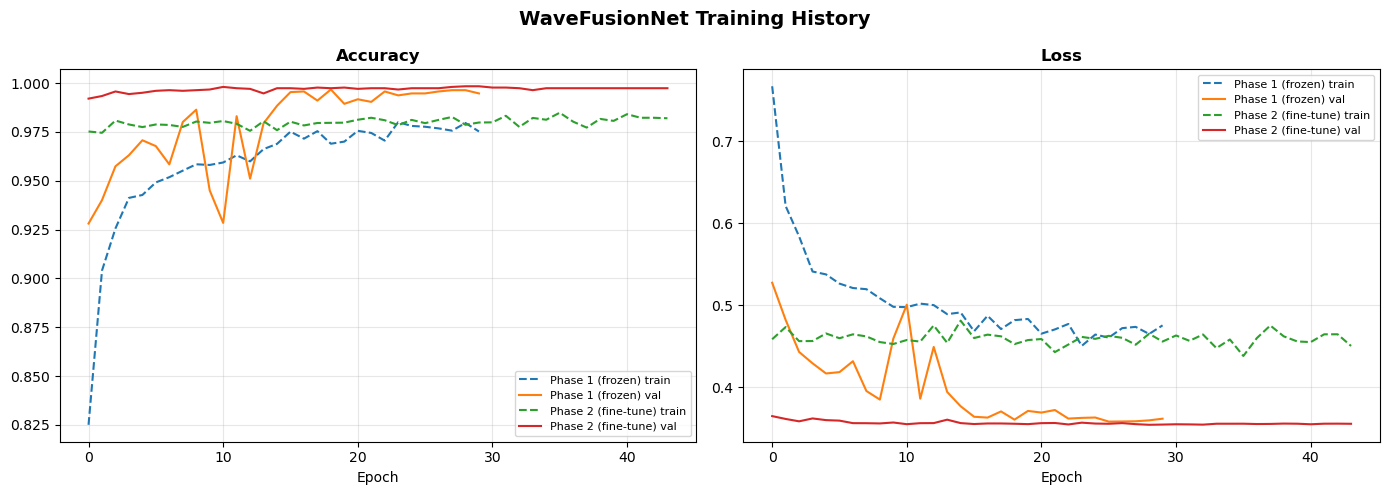

Best val accuracy — Phase 1: 0.9967 | Phase 2: 0.9983
Training complete


In [15]:
# ============================================================
# SECTION 9 — TWO-PHASE TRAINING
# ============================================================

y_val_cat = keras.utils.to_categorical(y_val, cfg.NUM_CLASSES)

def make_callbacks(name, monitor="val_loss", use_lr_plateau=True):
    ckpt = os.path.join(cfg.OUTPUT_DIR, "models", f"{name}_best.keras")
    cbs = [
        EarlyStopping(monitor=monitor, patience=15,  # A10G is fast — afford more patience
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(ckpt, monitor=monitor, save_best_only=True, verbose=0),
    ]
    if use_lr_plateau:
        cbs.insert(0, ReduceLROnPlateau(monitor=monitor, factor=0.5, patience=5,
                                         verbose=1, min_lr=1e-7))
    return cbs


# ═══ PHASE 1: Frozen backbones — train custom layers only ════
print("=" * 60)
print("  PHASE 1 — Frozen Backbones (training custom layers)")
print("=" * 60)

eff_base.trainable = False
dense_base.trainable = False

model.compile(
    optimizer=Adam(learning_rate=cfg.LR_P1),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=cfg.LABEL_SMOOTH),
    metrics=["accuracy"],
)

trainable_count = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f"Trainable parameters: {trainable_count:,}")

hist_p1 = model.fit(
    train_gen,
    validation_data=(X_val, y_val_cat),
    epochs=cfg.EPOCHS_P1,
    callbacks=make_callbacks("wavefusion_phase1", use_lr_plateau=True),
    class_weight=class_weights,
    verbose=1,
)


# ── Free Phase 1 optimizer state before Phase 2 ──
gc.collect()

# ═══ PHASE 2: Fine-tune top layers of both backbones ═════════
print("" + "=" * 60)
print("  PHASE 2 — Fine-Tuning (unfreezing top backbone layers)")
print("=" * 60)

eff_base.trainable = True
dense_base.trainable = True

for layer in eff_base.layers[:-40]:
    layer.trainable = False
for layer in dense_base.layers[:-40]:
    layer.trainable = False

# Cosine decay — no ReduceLROnPlateau needed
steps_per_epoch = len(train_gen)
total_steps = steps_per_epoch * cfg.EPOCHS_P2
cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=cfg.LR_P2,
    decay_steps=total_steps,
    alpha=1e-7,
)

model.compile(
    optimizer=Adam(learning_rate=cosine_schedule),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=cfg.LABEL_SMOOTH),
    metrics=["accuracy"],
)

trainable_count = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f"Trainable parameters: {trainable_count:,}")

hist_p2 = model.fit(
    train_gen,
    validation_data=(X_val, y_val_cat),
    epochs=cfg.EPOCHS_P2,
    callbacks=make_callbacks("wavefusion_phase2", use_lr_plateau=False),
    class_weight=class_weights,
    verbose=1,
)

model.save(os.path.join(cfg.OUTPUT_DIR, "models", "wavefusionnet_final.keras"))

# ── Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, label in [(hist_p1, "Phase 1 (frozen)"), (hist_p2, "Phase 2 (fine-tune)")]:
    axes[0].plot(hist.history["accuracy"], label=f"{label} train", linestyle="--")
    axes[0].plot(hist.history["val_accuracy"], label=f"{label} val")
    axes[1].plot(hist.history["loss"], label=f"{label} train", linestyle="--")
    axes[1].plot(hist.history["val_loss"], label=f"{label} val")
for ax, title in zip(axes, ["Accuracy", "Loss"]):
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("Epoch")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("WaveFusionNet Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "plots", "training_history.png"), dpi=150, bbox_inches="tight")
plt.show()

best_p1 = max(hist_p1.history["val_accuracy"])
best_p2 = max(hist_p2.history["val_accuracy"])
print(f"Best val accuracy — Phase 1: {best_p1:.4f} | Phase 2: {best_p2:.4f}")
print("Training complete")


---
## Phase 5 — Feature Extraction & Tri-Head Ensemble (Novel)

### 5.1 — Extract Bottleneck Features
Tap the `bottleneck` dense layer (256-d) for downstream SVM and XGBoost classifiers.

### 5.2 — Train SVM (RBF) + XGBoost on Fused Features
### 5.3 — Optimized Weighted Ensemble
Grid search over weight combinations (w1, w2, w3) to find the optimal blend of:
- **Softmax** (end-to-end trained neural network head)
- **SVM** (maximum-margin classifier in feature space)
- **XGBoost** (gradient boosted trees — complementary non-neural approach)

### 5.4 — Test-Time Augmentation (TTA)
Average ensemble predictions over multiple augmented versions of each test image.

In [2]:
# ============================================================
# ALL-IN-ONE RECOVERY + DATA LOADING
# ============================================================
import os, gc, pickle, json, random, warnings
import numpy as np
import h5py
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from itertools import product as iter_product
from tqdm.notebook import tqdm
from PIL import Image
import cv2
import pywt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

# GPU setup
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
tf.keras.mixed_precision.set_global_policy("mixed_float16")

# Seeds
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Config
class Config:
    DATASET_ROOT = "/home/sagemaker-user/dataset2"
    TRAIN_DIR    = "/home/sagemaker-user/dataset2/Training"
    TEST_DIR     = "/home/sagemaker-user/dataset2/Testing"
    OUTPUT_DIR   = "/home/sagemaker-user/outputs_wavefusionnet"
    IMG_SIZE     = (224, 224)
    INPUT_SHAPE  = (224, 224, 3)
    CLASS_NAMES  = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]
    NUM_CLASSES  = 4
    VAL_SPLIT    = 0.2
    EMBED_DIM    = 256
    NUM_HEADS    = 4
    BATCH_SIZE   = 16
    TTA_AUGMENTS = 10
    CLAHE_CLIP   = 2.0
    CLAHE_TILE   = (8, 8)
    CROP_BRAIN   = True
    WAVELET      = "db2"
    WAVELET_LVL  = 2
    EDGE_BOOST   = 1.0

cfg = Config()

# Custom model classes
class ChannelAttention(layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
    def build(self, input_shape):
        ch = input_shape[-1]
        self.fc1 = layers.Dense(max(ch // self.ratio, 1), activation="relu", name=self.name + "_fc1")
        self.fc2 = layers.Dense(ch, name=self.name + "_fc2")
    def call(self, x):
        avg_pool = tf.reduce_mean(x, axis=[1, 2], keepdims=True)
        max_pool = tf.reduce_max(x, axis=[1, 2], keepdims=True)
        avg_out = self.fc2(self.fc1(avg_pool))
        max_out = self.fc2(self.fc1(max_pool))
        return x * tf.sigmoid(avg_out + max_out)
    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
    def build(self, input_shape):
        self.conv = layers.Conv2D(1, self.kernel_size, padding="same", activation="sigmoid", name=self.name + "_conv")
    def call(self, x):
        avg_pool = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(x, axis=-1, keepdims=True)
        return x * self.conv(tf.concat([avg_pool, max_pool], axis=-1))
    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

class CBAM(layers.Layer):
    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
        self.kernel_size = kernel_size
    def build(self, input_shape):
        self.ca = ChannelAttention(self.ratio, name=self.name + "_ca")
        self.sa = SpatialAttention(self.kernel_size, name=self.name + "_sa")
    def call(self, x):
        return self.sa(self.ca(x))
    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio, "kernel_size": self.kernel_size})
        return config

class CrossAttentionFusion(layers.Layer):
    def __init__(self, embed_dim=256, num_heads=4, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
    def build(self, input_shape):
        key_dim = self.embed_dim // self.num_heads
        self.mha_ab = layers.MultiHeadAttention(num_heads=self.num_heads, key_dim=key_dim, name=self.name + "_mha_ab")
        self.mha_ba = layers.MultiHeadAttention(num_heads=self.num_heads, key_dim=key_dim, name=self.name + "_mha_ba")
        self.norm_a = layers.LayerNormalization(name=self.name + "_ln_a")
        self.norm_b = layers.LayerNormalization(name=self.name + "_ln_b")
        self.proj   = layers.Dense(self.embed_dim, activation="relu", name=self.name + "_proj")
        self.dropout = layers.Dropout(0.1)
    def call(self, inputs, training=False):
        feat_a, feat_b = inputs
        attn_ab = self.mha_ab(query=feat_a, key=feat_b, value=feat_b)
        attn_ab = self.norm_a(feat_a + attn_ab)
        attn_ba = self.mha_ba(query=feat_b, key=feat_a, value=feat_a)
        attn_ba = self.norm_b(feat_b + attn_ba)
        fused   = self.proj(tf.concat([attn_ab, attn_ba], axis=-1))
        return self.dropout(fused, training=training)
    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim, "num_heads": self.num_heads})
        return config

@tf.keras.utils.register_keras_serializable()
def preprocess_effnet(x):
    return tf.cast(x, tf.float32) * 2.0 - 1.0

@tf.keras.utils.register_keras_serializable()
def preprocess_densenet(x):
    x    = tf.cast(x, tf.float32)
    mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
    std  = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)
    return (x - mean) / std

# Load model
custom_objects = {
    "ChannelAttention": ChannelAttention,
    "SpatialAttention": SpatialAttention,
    "CBAM": CBAM,
    "CrossAttentionFusion": CrossAttentionFusion,
    "preprocess_effnet": preprocess_effnet,
    "preprocess_densenet": preprocess_densenet,
}
model_path = os.path.join(cfg.OUTPUT_DIR, "models", "wavefusionnet_final.keras")
model = keras.models.load_model(model_path, custom_objects=custom_objects)
print(f"✅ Model loaded — {model.count_params():,} parameters")

# Load data from HDF5
TRAIN_HDF5 = os.path.join(cfg.OUTPUT_DIR, "features", "train_preprocessed.h5")
TEST_HDF5  = os.path.join(cfg.OUTPUT_DIR, "features", "test_preprocessed.h5")
feat_dir   = os.path.join(cfg.OUTPUT_DIR, "features")

print("Loading labels...")
with h5py.File(TRAIN_HDF5, "r") as hf:
    y_train_full = hf["labels"][:]
with h5py.File(TEST_HDF5, "r") as hf:
    y_test = hf["labels"][:]

train_idx, val_idx = train_test_split(
    np.arange(len(y_train_full)),
    test_size=cfg.VAL_SPLIT, random_state=SEED, stratify=y_train_full
)
y_train = y_train_full[train_idx]
y_val   = y_train_full[val_idx]

print("Loading X_val...")
with h5py.File(TRAIN_HDF5, "r") as hf:
    X_val = hf["images"][np.sort(val_idx)].astype(np.float32) / 255.0

print("Loading X_test...")
with h5py.File(TEST_HDF5, "r") as hf:
    X_test = hf["images"][:].astype(np.float32) / 255.0

print("Loading features...")
F_train = np.load(os.path.join(feat_dir, "F_train.npy"))
F_val   = np.load(os.path.join(feat_dir, "F_val.npy"))
F_test  = np.load(os.path.join(feat_dir, "F_test.npy"))

print("\n✅ Everything loaded:")
print(f"   y_train: {y_train.shape} | y_val: {y_val.shape} | y_test: {y_test.shape}")
print(f"   X_val:   {X_val.shape}  | X_test: {X_test.shape}")
print(f"   F_train: {F_train.shape} | F_val: {F_val.shape} | F_test: {F_test.shape}")
print("\n✅ Ready for Section 11")

2026-05-07 07:23:55.653636: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778138635.669901    5935 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778138635.674831    5935 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1778138638.086421    5935 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20795 MB memory:  -> device: 0, name: NVIDIA A10G, pci bus id: 0000:00:1e.0, compute capability: 8.6


✅ Model loaded — 40,267,178 parameters
Loading labels...
Loading X_val...
Loading X_test...
Loading features...

✅ Everything loaded:
   y_train: (12008,) | y_val: (3002,) | y_test: (5747,)
   X_val:   (3002, 224, 224, 3)  | X_test: (5747, 224, 224, 3)
   F_train: (12008, 256) | F_val: (3002, 256) | F_test: (5747, 256)

✅ Ready for Section 11


In [3]:
# Required variables for Section 10
import h5py
from sklearn.model_selection import train_test_split

SEED = 42
LOCAL_TRAIN = "/home/sagemaker-user/outputs_wavefusionnet/features/train_preprocessed.h5"
LOCAL_TEST  = "/home/sagemaker-user/outputs_wavefusionnet/features/test_preprocessed.h5"

# Load full labels to recreate split
with h5py.File(LOCAL_TRAIN, "r") as hf:
    y_train_full = hf["labels"][:]

# Recreate exact same split
train_idx, val_idx = train_test_split(
    np.arange(len(y_train_full)),
    test_size=cfg.VAL_SPLIT, random_state=SEED, stratify=y_train_full
)

# Load X_val and X_test
with h5py.File(LOCAL_TRAIN, "r") as hf:
    X_val = hf["images"][np.sort(val_idx)].astype(np.float32) / 255.0
with h5py.File(LOCAL_TEST, "r") as hf:
    X_test  = hf["images"][:].astype(np.float32) / 255.0
    y_test  = hf["labels"][:]

feat_extractor = keras.Model(
    inputs=model.input,
    outputs=model.get_layer("relu_bottleneck").output,
    name="FeatureExtractor"
)
print("✅ Ready to run Section 10")

✅ Ready to run Section 10


In [6]:
# ============================================================
# SECTION 10 — FEATURE EXTRACTION FROM BOTTLENECK LAYER
# ============================================================

from sklearn.manifold import TSNE

# Create feature extractor (bottleneck output)
feat_extractor = keras.Model(
    inputs=model.input,
    outputs=model.get_layer("relu_bottleneck").output,
    name="FeatureExtractor"
)

def hdf5_batch_predict(extractor, hdf5_path, indices, batch_size=32):
    """Extract features in batches from HDF5 - no full dataset in RAM."""
    results = []
    for start in tqdm(range(0, len(indices), batch_size), desc="Extracting train"):
        batch_idx = np.sort(indices[start:start + batch_size])
        with h5py.File(hdf5_path, "r") as hf:
            batch = hf["images"][list(batch_idx)].astype(np.float32) / 255.0
        results.append(extractor.predict(batch, verbose=0))
    return np.vstack(results)

print("Extracting features from WaveFusionNet bottleneck...")
F_train = hdf5_batch_predict(feat_extractor, LOCAL_TRAIN, train_idx)
F_val   = feat_extractor.predict(X_val,   batch_size=32, verbose=1)
F_test  = feat_extractor.predict(X_test,  batch_size=32, verbose=1)

print(f"\nFeature dimensions: Train {F_train.shape} | Val {F_val.shape} | Test {F_test.shape}")

# Save features
np.save(os.path.join(cfg.OUTPUT_DIR, "features", "F_train.npy"), F_train)
np.save(os.path.join(cfg.OUTPUT_DIR, "features", "F_val.npy"),   F_val)
np.save(os.path.join(cfg.OUTPUT_DIR, "features", "F_test.npy"),  F_test)

# t-SNE visualization
print("Running t-SNE visualization...")
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
F_2d = tsne.fit_transform(F_test)

plt.figure(figsize=(9, 7))
for idx, cls in enumerate(cfg.CLASS_NAMES):
    mask = y_test == idx
    plt.scatter(F_2d[mask, 0], F_2d[mask, 1], label=cls,
                color=COLORS[idx], alpha=0.6, s=20, edgecolors="none")
plt.legend(fontsize=10, markerscale=2)
plt.title("t-SNE of WaveFusionNet Fused Features (Test Set)", fontsize=13, fontweight="bold")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "plots", "tsne_features.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Feature extraction complete")

Extracting features from WaveFusionNet bottleneck...


Extracting train:   0%|          | 0/376 [00:00<?, ?it/s]

94/94 ━━━━━━━━━━━━━━━━━━━━ 36s 389ms/step
180/180 ━━━━━━━━━━━━━━━━━━━━ 39s 219ms/step

Feature dimensions: Train (12008, 256) | Val (3002, 256) | Test (5747, 256)
Running t-SNE visualization...


NameError: name 'plt' is not defined

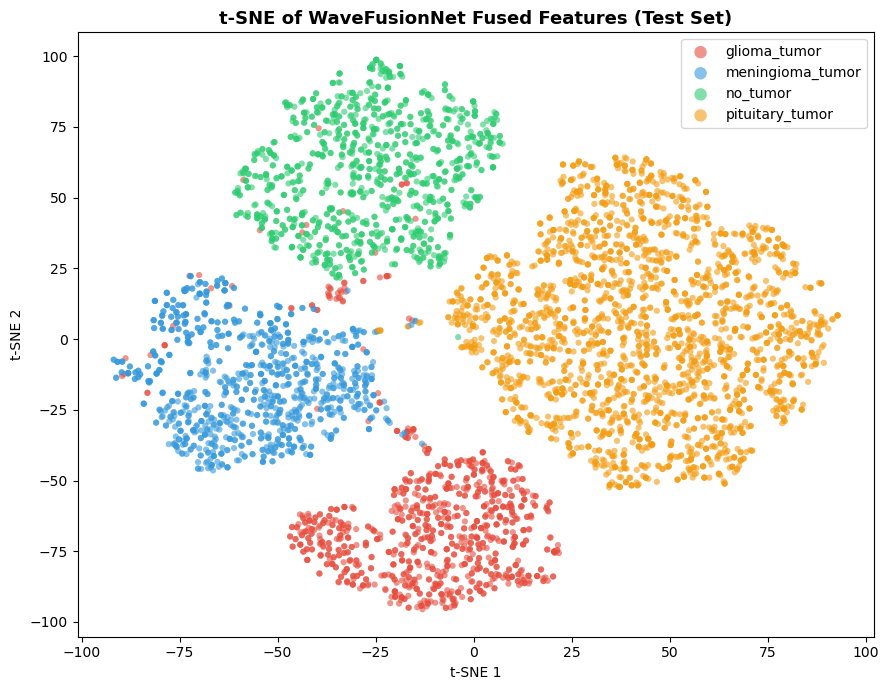

Feature extraction complete


In [7]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

COLORS = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
F_2d = tsne.fit_transform(F_test)

plt.figure(figsize=(9, 7))
for idx, cls in enumerate(cfg.CLASS_NAMES):
    mask = y_test == idx
    plt.scatter(F_2d[mask, 0], F_2d[mask, 1], label=cls,
                color=COLORS[idx], alpha=0.6, s=20, edgecolors="none")
plt.legend(fontsize=10, markerscale=2)
plt.title("t-SNE of WaveFusionNet Fused Features (Test Set)", fontsize=13, fontweight="bold")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "plots", "tsne_features.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Feature extraction complete")

In [10]:
# ── Apply CORRECT labels ──
y_train = y_train_CORRECT
y_val   = y_val_CORRECT
print(f"✅ Labels fixed: y_train {y_train.shape} | y_val {y_val.shape}")

✅ Labels fixed: y_train (12008,) | y_val (3002,)


In [11]:
# ============================================================
# SECTION 11 — SVM + XGBOOST + WEIGHTED ENSEMBLE
# ============================================================
# FIX: GridSearchCV now uses ONLY training data (no val leakage).
# FIX: Ensemble weights use coarser grid (0.1 steps) to reduce
#      overfitting on 574 val samples.
# ============================================================
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from itertools import product as iter_product
from tqdm import tqdm

# Scale features (mandatory for SVM)
scaler = StandardScaler()
F_tr_sc = scaler.fit_transform(F_train)
F_va_sc = scaler.transform(F_val)
F_te_sc = scaler.transform(F_test)

# ═══ SVM with Progress Bar ════════════════════════════════════
print("Training SVM (GridSearchCV 5-fold on TRAIN only)...")

C_vals       = [0.1, 1, 10, 100]
gamma_vals   = ["scale", 0.001, 0.01]
param_combos = list(iter_product(C_vals, gamma_vals))
n_folds      = 5
total_fits   = len(param_combos) * n_folds  # 60

skf         = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
best_score  = -1
best_params = {}

pbar = tqdm(
    total=total_fits,
    desc="SVM GridSearch",
    unit="fit",
    bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} fits | Elapsed: {elapsed} | ETA: {remaining}"
)

for C, gamma in param_combos:
    fold_scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(F_tr_sc, y_train)):
        clf = SVC(kernel="rbf", C=C, gamma=gamma,
                  probability=True, random_state=SEED)
        clf.fit(F_tr_sc[tr_idx], y_train[tr_idx])
        score = clf.score(F_tr_sc[va_idx], y_train[va_idx])
        fold_scores.append(score)
        pbar.set_postfix({
            "C"      : C,
            "gamma"  : gamma,
            "fold"   : f"{fold_idx+1}/{n_folds}",
            "acc"    : f"{score:.4f}",
            "best"   : f"{best_score:.4f}" if best_score > 0 else "N/A"
        })
        pbar.update(1)

    mean_score = np.mean(fold_scores)
    if mean_score > best_score:
        best_score  = mean_score
        best_params = {"C": C, "gamma": gamma}

pbar.close()

# Final SVM on full training data
print(f"\nBest params: {best_params} | CV acc: {best_score:.4f}")
print("Fitting final SVM on full training set...")
svm_clf = SVC(kernel="rbf", probability=True, random_state=SEED, **best_params)
svm_clf.fit(F_tr_sc, y_train)
print(f"SVM val acc (unseen): {svm_clf.score(F_va_sc, y_val):.4f}")

# ═══ XGBoost ══════════════════════════════════════════════════
print("\nTraining XGBoost...")
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric="mlogloss",
    random_state=SEED, n_jobs=-1,
)
xgb_clf.fit(F_tr_sc, y_train,
            eval_set=[(F_va_sc, y_val)], verbose=False)
xgb_val_acc = accuracy_score(y_val, xgb_clf.predict(F_va_sc))
print(f"XGBoost val acc: {xgb_val_acc:.4f}")

# ═══ Optimize ensemble weights ════════════════════════════════
print("\nOptimizing ensemble weights (0.1 step grid)...")
y_val_cat     = keras.utils.to_categorical(y_val, cfg.NUM_CLASSES)
softmax_val_p = model.predict(X_val, batch_size=32, verbose=0)
svm_val_p     = svm_clf.predict_proba(F_va_sc)
xgb_val_p     = xgb_clf.predict_proba(F_va_sc)

best_acc, best_w = 0, (1/3, 1/3, 1/3)
w_combos = [(w1, w2) for w1 in np.arange(0.1, 0.9, 0.1)
                      for w2 in np.arange(0.1, 0.9 - w1, 0.1)
                      if round(1.0 - w1 - w2, 2) >= 0.05]

for w1, w2 in tqdm(w_combos, desc="Ensemble weights", unit="combo"):
    w3    = round(1.0 - w1 - w2, 2)
    ens_p = w1 * softmax_val_p + w2 * svm_val_p + w3 * xgb_val_p
    acc   = accuracy_score(y_val, np.argmax(ens_p, axis=1))
    if acc > best_acc:
        best_acc = acc
        best_w   = (round(float(w1), 2), round(float(w2), 2), round(float(w3), 2))

print(f"\nOptimal ensemble weights:")
print(f"  Softmax = {best_w[0]} | SVM = {best_w[1]} | XGBoost = {best_w[2]}")
print(f"  Ensemble val accuracy: {best_acc:.4f}")

# ═══ Save all classifiers ═════════════════════════════════════
with open(os.path.join(cfg.OUTPUT_DIR, "models", "svm_clf.pkl"), "wb") as f:
    pickle.dump(svm_clf, f)
with open(os.path.join(cfg.OUTPUT_DIR, "models", "xgb_clf.pkl"), "wb") as f:
    pickle.dump(xgb_clf, f)
with open(os.path.join(cfg.OUTPUT_DIR, "models", "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
with open(os.path.join(cfg.OUTPUT_DIR, "models", "ensemble_weights.json"), "w") as f:
    json.dump({"softmax": best_w[0], "svm": best_w[1], "xgb": best_w[2]}, f)

print("\nSVM + XGBoost + Ensemble optimization complete (no data leakage)")

Training SVM (GridSearchCV 5-fold on TRAIN only)...


SVM GridSearch: 100%|██████████| 60/60 fits | Elapsed: 00:47 | ETA: 00:00



Best params: {'C': 100, 'gamma': 'scale'} | CV acc: 0.9996
Fitting final SVM on full training set...
SVM val acc (unseen): 0.9980

Training XGBoost...
XGBoost val acc: 0.9980

Optimizing ensemble weights (0.1 step grid)...


Ensemble weights: 100%|██████████| 30/30 [00:00<00:00, 1784.73combo/s]


Optimal ensemble weights:
  Softmax = 0.1 | SVM = 0.1 | XGBoost = 0.8
  Ensemble val accuracy: 0.9980

SVM + XGBoost + Ensemble optimization complete (no data leakage)


In [13]:
# Recreate feature extractor
from tensorflow.keras.preprocessing.image import ImageDataGenerator

feat_extractor = keras.Model(
    inputs=model.input,
    outputs=model.get_layer("relu_bottleneck").output,
    name="FeatureExtractor"
)
print("✅ feat_extractor ready")

✅ feat_extractor ready


In [14]:
# ============================================================
# SECTION 12 — TEST-TIME AUGMENTATION (TTA) + PREDICTIONS
# ============================================================

def test_time_augmentation(model, feat_extractor, svm_clf, xgb_clf, scaler,
                           images, n_aug=10, weights=None):
    """
    Test-Time Augmentation: average ensemble predictions over multiple
    augmented versions of each test image for more robust inference.
    """
    if weights is None:
        weights = (1/3, 1/3, 1/3)

    tta_datagen = ImageDataGenerator(
        rotation_range=15, width_shift_range=0.08, height_shift_range=0.08,
        zoom_range=0.1, horizontal_flip=True, fill_mode="nearest"
    )

    all_probas = []

    # Original (unaugmented) prediction
    sm_p = model.predict(images, batch_size=32, verbose=0)
    feats = feat_extractor.predict(images, batch_size=32, verbose=0)
    feats_sc = scaler.transform(feats)
    sv_p = svm_clf.predict_proba(feats_sc)
    xg_p = xgb_clf.predict_proba(feats_sc)
    all_probas.append(weights[0] * sm_p + weights[1] * sv_p + weights[2] * xg_p)

    # Augmented predictions
    for i in tqdm(range(n_aug), desc="TTA augmentations"):
        aug_imgs = np.array([tta_datagen.random_transform(img) for img in images])
        sm_p = model.predict(aug_imgs, batch_size=32, verbose=0)
        ft = feat_extractor.predict(aug_imgs, batch_size=32, verbose=0)
        ft_sc = scaler.transform(ft)
        sv_p = svm_clf.predict_proba(ft_sc)
        xg_p = xgb_clf.predict_proba(ft_sc)
        all_probas.append(weights[0] * sm_p + weights[1] * sv_p + weights[2] * xg_p)

    avg_proba = np.mean(all_probas, axis=0)
    return np.argmax(avg_proba, axis=1), avg_proba


# ── Generate ALL predictions ──────────────────────────────────
print("Generating predictions with all methods...")

# Individual classifiers
softmax_test_p = model.predict(X_test, batch_size=32, verbose=0)
svm_test_p     = svm_clf.predict_proba(F_te_sc)
xgb_test_p     = xgb_clf.predict_proba(F_te_sc)

y_pred_softmax = np.argmax(softmax_test_p, axis=1)
y_pred_svm     = svm_clf.predict(F_te_sc)
y_pred_xgb     = xgb_clf.predict(F_te_sc)

# Ensemble without TTA
ens_test_p     = best_w[0]*softmax_test_p + best_w[1]*svm_test_p + best_w[2]*xgb_test_p
y_pred_ens     = np.argmax(ens_test_p, axis=1)

# Ensemble with TTA
print("\nRunning Test-Time Augmentation...")
y_pred_tta, y_proba_tta = test_time_augmentation(
    model, feat_extractor, svm_clf, xgb_clf, scaler,
    X_test, n_aug=cfg.TTA_AUGMENTS, weights=best_w
)

print(f"\n{'='*50}")
print(f"  TEST SET ACCURACY COMPARISON")
print(f"{'='*50}")
print(f"  Softmax only      : {accuracy_score(y_test, y_pred_softmax):.4f}")
print(f"  SVM only           : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"  XGBoost only       : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  Ensemble (no TTA)  : {accuracy_score(y_test, y_pred_ens):.4f}")
print(f"  Ensemble + TTA     : {accuracy_score(y_test, y_pred_tta):.4f}")
print(f"{'='*50}")

Generating predictions with all methods...

Running Test-Time Augmentation...


TTA augmentations: 100%|██████████| 10/10 [11:58<00:00, 71.82s/it]


  TEST SET ACCURACY COMPARISON
  Softmax only      : 0.9859
  SVM only           : 0.9868
  XGBoost only       : 0.9868
  Ensemble (no TTA)  : 0.9868
  Ensemble + TTA     : 0.9869


---
## Phase 6 — Comprehensive Evaluation

### Metrics:
- Confusion Matrix
- Per-class: Sensitivity, Specificity, Precision, F1-Score
- Dice Similarity Coefficient (DSC)
- ROC-AUC Curves
- Grad-CAM++ Attention Visualization
- Real-Time Prediction Pipeline

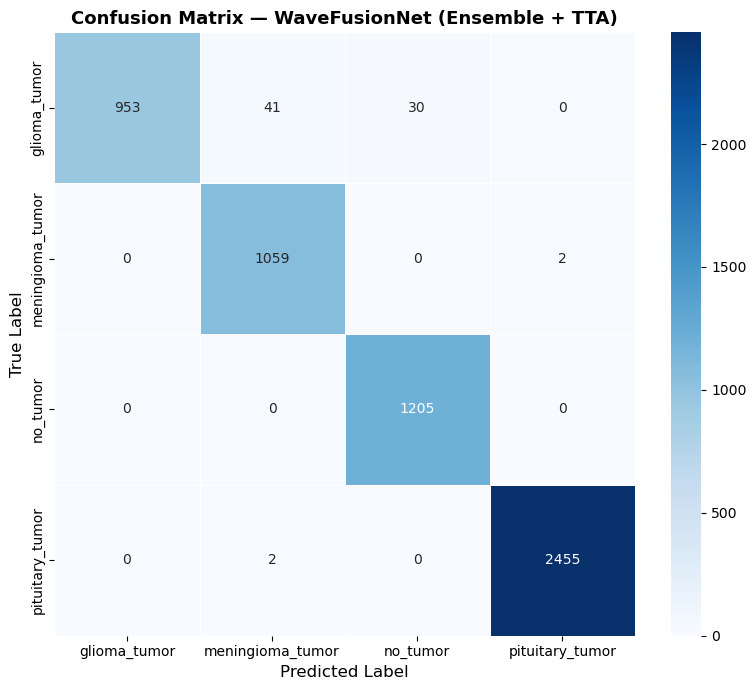

Per-Class Metrics:
           Class   TP  FP  FN   TN  Sensitivity  Specificity  Precision  F1-Score
    glioma_tumor  953   0  71 4723       0.9307       1.0000     1.0000    0.9641
meningioma_tumor 1059  43   2 4643       0.9981       0.9908     0.9610    0.9792
        no_tumor 1205  30   0 4512       1.0000       0.9934     0.9757    0.9877
 pituitary_tumor 2455   2   2 3288       0.9992       0.9994     0.9992    0.9992

                  precision    recall  f1-score   support

    glioma_tumor     1.0000    0.9307    0.9641      1024
meningioma_tumor     0.9610    0.9981    0.9792      1061
        no_tumor     0.9757    1.0000    0.9877      1205
 pituitary_tumor     0.9992    0.9992    0.9992      2457

        accuracy                         0.9869      5747
       macro avg     0.9840    0.9820    0.9825      5747
    weighted avg     0.9874    0.9869    0.9868      5747

Overall Accuracy : 0.9869
Macro F1-Score   : 0.9825


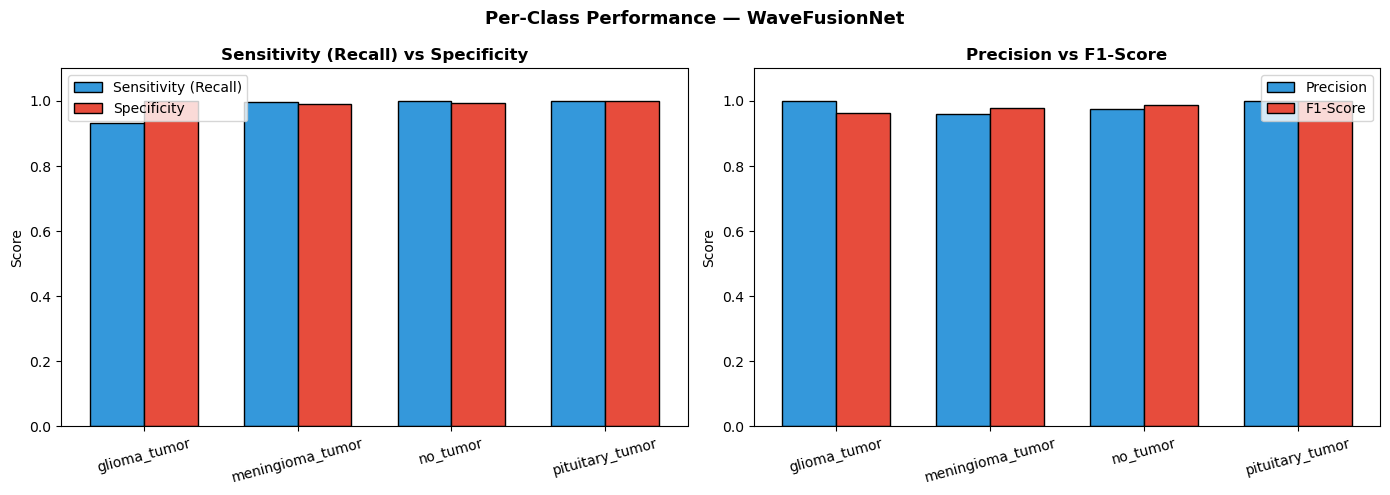

In [17]:
# ============================================================
# SECTION 13 — CONFUSION MATRIX + PER-CLASS METRICS
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import pandas as pd

# Use best predictions (Ensemble + TTA)
y_pred  = y_pred_tta
y_proba = y_proba_tta

# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
           xticklabels=cfg.CLASS_NAMES, yticklabels=cfg.CLASS_NAMES,
           linewidths=0.5, ax=ax)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix — WaveFusionNet (Ensemble + TTA)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "plots", "confusion_matrix.png"),
            dpi=150, bbox_inches="tight")
plt.show()


# ── Per-class metrics ─────────────────────────────────────────
def per_class_metrics(cm, class_names):
    rows = []
    for i, cls in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FP - FN
        sens = TP / (TP + FN + 1e-8)
        spec = TN / (TN + FP + 1e-8)
        prec = TP / (TP + FP + 1e-8)
        f1   = 2 * prec * sens / (prec + sens + 1e-8)
        rows.append({
            "Class": cls,
            "TP": int(TP), "FP": int(FP), "FN": int(FN), "TN": int(TN),
            "Sensitivity": round(sens, 4),
            "Specificity": round(spec, 4),
            "Precision":   round(prec, 4),
            "F1-Score":    round(f1,   4),
        })
    return pd.DataFrame(rows)


metrics_df = per_class_metrics(cm, cfg.CLASS_NAMES)
print("Per-Class Metrics:")
print(metrics_df.to_string(index=False))

print("\n" + classification_report(y_test, y_pred, target_names=cfg.CLASS_NAMES, digits=4))

oa  = accuracy_score(y_test, y_pred)
mf1 = f1_score(y_test, y_pred, average="macro")
print(f"Overall Accuracy : {oa:.4f}")
print(f"Macro F1-Score   : {mf1:.4f}")

# ── Per-class bar chart ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(cfg.NUM_CLASSES)
w = 0.35

for ax, (col_a, col_b, la, lb) in zip(
    axes,
    [("Sensitivity", "Specificity", "Sensitivity (Recall)", "Specificity"),
     ("Precision",   "F1-Score",    "Precision",            "F1-Score")]
):
    ax.bar(x - w/2, metrics_df[col_a], w, label=la, color="#3498db", edgecolor="black")
    ax.bar(x + w/2, metrics_df[col_b], w, label=lb, color="#e74c3c", edgecolor="black")
    ax.set_xticks(x); ax.set_xticklabels(cfg.CLASS_NAMES, rotation=15)
    ax.set_ylim(0, 1.1); ax.set_ylabel("Score"); ax.legend()
    ax.set_title(f"{la} vs {lb}", fontweight="bold")

plt.suptitle("Per-Class Performance — WaveFusionNet", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "plots", "per_class_metrics.png"),
            dpi=150, bbox_inches="tight")
plt.show()

  Dice Similarity Coefficient (DSC)
           Class    DSC  Pred Positives  True Positives  Intersection
    glioma_tumor 0.9641             953            1024           953
meningioma_tumor 0.9792            1102            1061          1059
        no_tumor 0.9877            1235            1205          1205
 pituitary_tumor 0.9992            2457            2457          2455

  Mean DSC: 0.9826


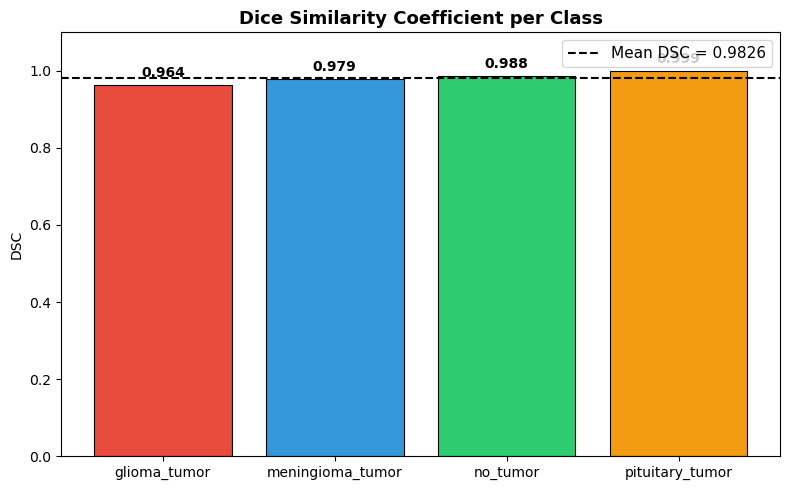

In [18]:
# ============================================================
# SECTION 14 — DICE SIMILARITY COEFFICIENT (DSC)
# ============================================================

def dice_similarity(y_true, y_pred, class_names):
    rows = []
    for c, cls in enumerate(class_names):
        X = (y_pred == c).astype(np.float32)
        Y = (y_true == c).astype(np.float32)
        intersection = np.sum(X * Y)
        dsc = (2.0 * intersection) / (np.sum(X) + np.sum(Y) + 1e-8)
        rows.append({"Class": cls, "DSC": round(float(dsc), 4),
                     "Pred Positives": int(X.sum()),
                     "True Positives": int(Y.sum()),
                     "Intersection": int(intersection)})
    return pd.DataFrame(rows)


dsc_df   = dice_similarity(y_test, y_pred, cfg.CLASS_NAMES)
mean_dsc = dsc_df["DSC"].mean()

print("=" * 55)
print("  Dice Similarity Coefficient (DSC)")
print("=" * 55)
print(dsc_df.to_string(index=False))
print(f"\n  Mean DSC: {mean_dsc:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dsc_df["Class"], dsc_df["DSC"], color=COLORS, edgecolor="black", lw=0.8)
ax.axhline(mean_dsc, color="black", linestyle="--", linewidth=1.5,
           label=f"Mean DSC = {mean_dsc:.4f}")
ax.set_ylim(0, 1.1); ax.set_ylabel("DSC")
ax.set_title("Dice Similarity Coefficient per Class", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
for b, v in zip(bars, dsc_df["DSC"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
            f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "plots", "dsc_scores.png"),
            dpi=150, bbox_inches="tight")
plt.show()

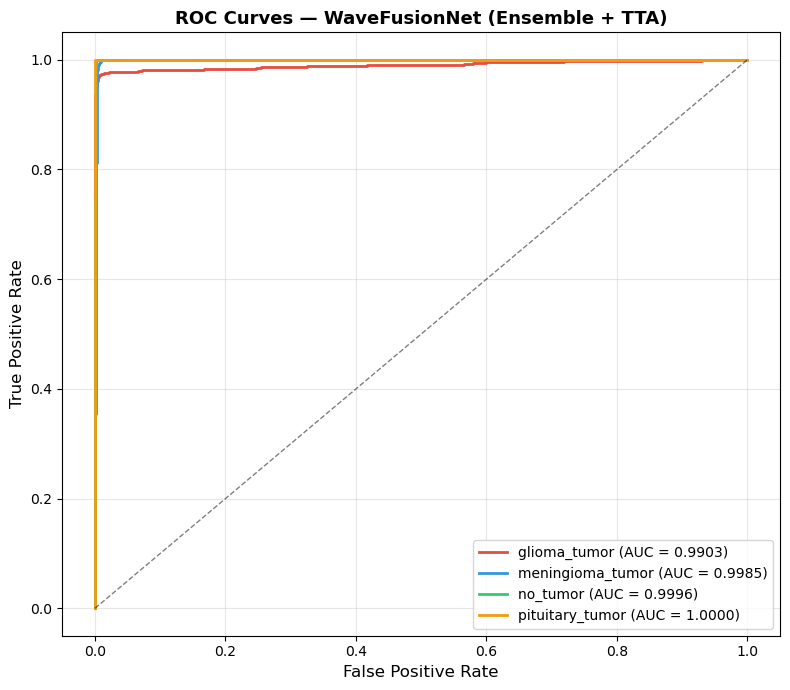

Per-class AUC: {'glioma_tumor': 0.9903, 'meningioma_tumor': 0.9985, 'no_tumor': 0.9996, 'pituitary_tumor': 1.0}
Mean AUC: 0.9971


In [20]:
# ============================================================
# SECTION 15 — ROC-AUC CURVES
# ============================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
y_test_bin = label_binarize(y_test, classes=range(cfg.NUM_CLASSES))

fig, ax = plt.subplots(figsize=(8, 7))
auc_scores = []
for i, cls in enumerate(cfg.CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc_val = auc(fpr, tpr)
    auc_scores.append(roc_auc_val)
    ax.plot(fpr, tpr, color=COLORS[i], linewidth=2,
            label=f"{cls} (AUC = {roc_auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, linewidth=1)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — WaveFusionNet (Ensemble + TTA)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "plots", "roc_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

mean_auc = np.mean(auc_scores)
print(f"Per-class AUC: {dict(zip(cfg.CLASS_NAMES, [round(a, 4) for a in auc_scores]))}")
print(f"Mean AUC: {mean_auc:.4f}")

In [22]:
from pathlib import Path
import cv2
import pywt

SUPPORTED_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif"}

def scan_dataset(root_dir, class_names):
    records = []
    for cls in class_names:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for f in Path(cls_dir).rglob("*"):
            if f.suffix.lower() in SUPPORTED_EXT:
                records.append({"filepath": str(f), "label": cls,
                               "label_idx": class_names.index(cls)})
    return pd.DataFrame(records)

def apply_clahe(image, clip=2.0, tile=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
    if image.ndim == 3:
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return clahe.apply(image)

def crop_brain_region(image, pad_pct=0.02):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if image.ndim == 3 else image.copy()
    _, binary = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(binary)
    if coords is None:
        return image
    x, y, w, h = cv2.boundingRect(coords)
    pad_x, pad_y = int(w * pad_pct), int(h * pad_pct)
    x, y = max(0, x - pad_x), max(0, y - pad_y)
    w = min(image.shape[1] - x, w + 2 * pad_x)
    h = min(image.shape[0] - y, h + 2 * pad_y)
    return cv2.resize(image[y:y+h, x:x+w], (image.shape[1], image.shape[0]),
                      interpolation=cv2.INTER_LANCZOS4)

def wavelet_enhance(image, wavelet="db2", level=2, edge_boost=1.0):
    enhanced_channels = []
    n_channels = image.shape[2] if image.ndim == 3 else 1
    for c in range(n_channels):
        channel = (image[:, :, c] if image.ndim == 3 else image).astype(np.float64)
        coeffs = pywt.wavedec2(channel, wavelet, level=level)
        sigma = np.median(np.abs(coeffs[-1][-1])) / 0.6745
        threshold = sigma * 0.5
        for i in range(1, len(coeffs)):
            coeffs[i] = tuple(pywt.threshold(d, threshold, mode="soft") * edge_boost for d in coeffs[i])
        recon = pywt.waverec2(coeffs, wavelet)
        recon = recon[:image.shape[0], :image.shape[1]]
        enhanced_channels.append(np.clip(recon, 0, 255))
    if image.ndim == 3:
        return np.stack(enhanced_channels, axis=-1).astype(np.uint8)
    return np.clip(enhanced_channels[0], 0, 255).astype(np.uint8)

def preprocess_image(path):
    try:
        img = Image.open(path).convert("RGB").resize(cfg.IMG_SIZE, Image.LANCZOS)
        img = np.array(img)
    except Exception:
        return None
    img = apply_clahe(img, cfg.CLAHE_CLIP, cfg.CLAHE_TILE)
    if cfg.CROP_BRAIN:
        img = crop_brain_region(img)
    img = wavelet_enhance(img, cfg.WAVELET, cfg.WAVELET_LVL, cfg.EDGE_BOOST)
    return img.astype(np.float32) / 255.0

print("✅ Helper functions ready")

✅ Helper functions ready


E0000 00:00:1778147183.209054    6001 buffer_comparator.cc:157] Difference at 16: 1.06738, expected 0.158813
E0000 00:00:1778147183.209100    6001 buffer_comparator.cc:157] Difference at 17: 0, expected 0.150269
E0000 00:00:1778147183.209105    6001 buffer_comparator.cc:157] Difference at 18: 0, expected 0.137085
E0000 00:00:1778147183.209109    6001 buffer_comparator.cc:157] Difference at 19: 1.44629, expected 0.135986
E0000 00:00:1778147183.209113    6001 buffer_comparator.cc:157] Difference at 20: 0, expected 0.155884
E0000 00:00:1778147183.209116    6001 buffer_comparator.cc:157] Difference at 21: 0.978516, expected 0.123535
E0000 00:00:1778147183.209120    6001 buffer_comparator.cc:157] Difference at 22: 0, expected 0.156372
E0000 00:00:1778147183.209123    6001 buffer_comparator.cc:157] Difference at 23: 1.02832, expected 0.134644
E0000 00:00:1778147183.209127    6001 buffer_comparator.cc:157] Difference at 24: 0, expected 0.143677
E0000 00:00:1778147183.209130    6001 buffer_com

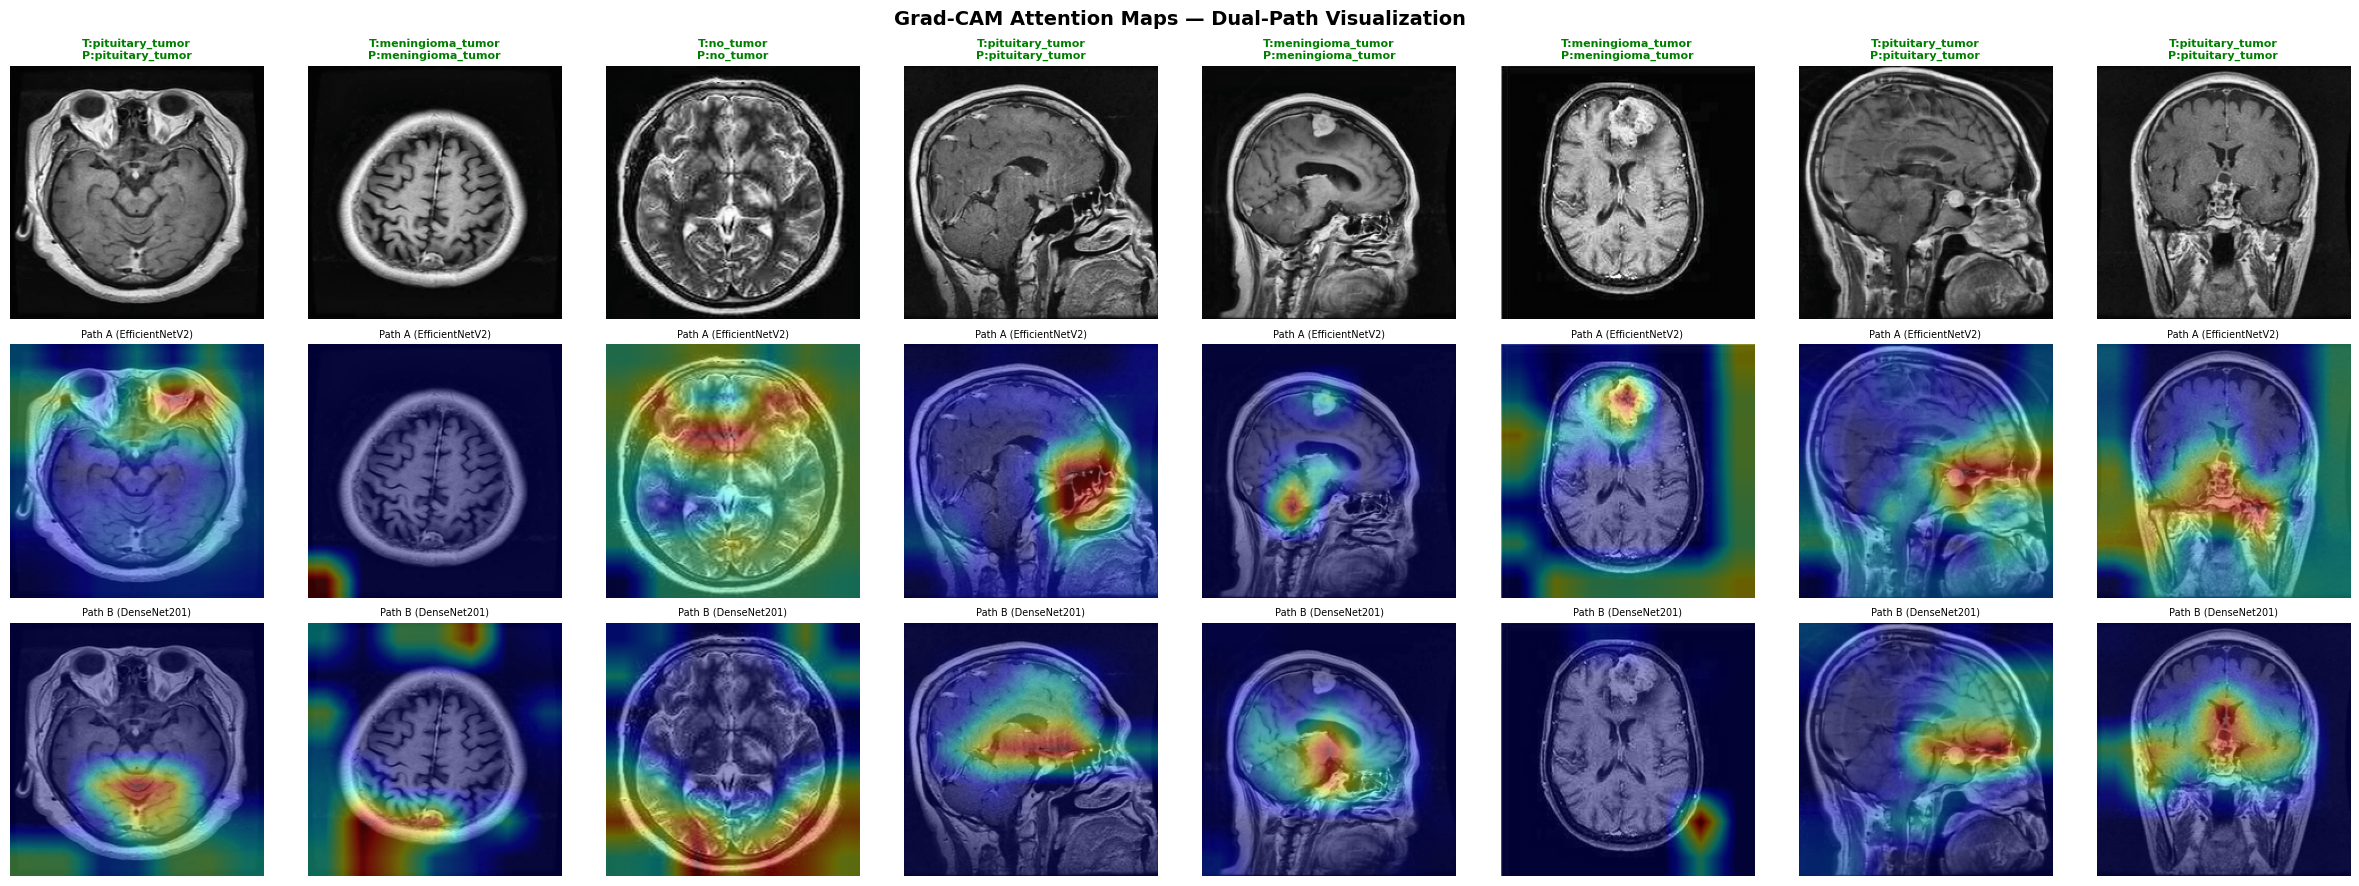

Grad-CAM visualization complete


In [23]:
# ============================================================
# SECTION 16 — GRAD-CAM ATTENTION VISUALIZATION
# ============================================================
# FIX: Force float32 policy during Grad-CAM to prevent
#      gradient underflow with mixed_float16.
# ============================================================

def compute_gradcam(model, image, layer_name="proj_a", pred_index=None):
    """Compute Grad-CAM heatmap for a given image and target layer."""
    img_batch = tf.cast(np.expand_dims(image, 0), tf.float32)

    if pred_index is None:
        preds = model.predict(img_batch.numpy(), verbose=0)
        pred_index = np.argmax(preds[0])

    try:
        target_layer = model.get_layer(layer_name)
        grad_model = keras.Model(
            model.input,
            [target_layer.output, model.output]
        )

        with tf.GradientTape() as tape:
            tape.watch(img_batch)
            conv_output, predictions = grad_model(img_batch, training=False)
            conv_output_f32 = tf.cast(conv_output, tf.float32)
            predictions_f32 = tf.cast(predictions, tf.float32)
            class_output = predictions_f32[:, pred_index]

        grads = tape.gradient(class_output, conv_output)
        if grads is None:
            print(f"Grad-CAM warning: no gradients for {layer_name}")
            return np.zeros(image.shape[:2]), pred_index

        grads = tf.cast(grads, tf.float32)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_output_f32 = tf.cast(conv_output[0], tf.float32)
        heatmap = conv_output_f32 @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
        heatmap = heatmap.numpy()

        heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
        return heatmap, pred_index
    except Exception as e:
        print(f"Grad-CAM error: {e}")
        return np.zeros(image.shape[:2]), pred_index


# Re-scan test set (safe for kernel restart or non-sequential execution)
if 'df_test' not in dir():
    df_test = scan_dataset(cfg.TEST_DIR, cfg.CLASS_NAMES)

# Visualize Grad-CAM on test samples
n_samples = 8
test_samples = df_test.sample(n_samples, random_state=SEED)

fig, axes = plt.subplots(3, n_samples, figsize=(3 * n_samples, 9))

for col, (_, row) in enumerate(test_samples.iterrows()):
    img = preprocess_image(row["filepath"])
    if img is None:
        continue

    # Grad-CAM from Path A (EfficientNetV2-S projection)
    cam_a, pred_idx = compute_gradcam(model, img, "proj_a")
    # Grad-CAM from Path B (DenseNet201 projection)
    cam_b, _ = compute_gradcam(model, img, "proj_b", pred_idx)

    pred_label = cfg.CLASS_NAMES[pred_idx]
    true_label = row["label"]
    color = "green" if pred_label == true_label else "red"

    # Row 0: Original image
    axes[0, col].imshow(img)
    axes[0, col].set_title(f"T:{true_label}\nP:{pred_label}",
                           fontsize=8, color=color, fontweight="bold")
    axes[0, col].axis("off")

    # Row 1: Grad-CAM Path A (EfficientNetV2-S)
    axes[1, col].imshow(img)
    axes[1, col].imshow(cam_a, cmap="jet", alpha=0.4)
    axes[1, col].set_title("Path A (EfficientNetV2)", fontsize=7)
    axes[1, col].axis("off")

    # Row 2: Grad-CAM Path B (DenseNet201)
    axes[2, col].imshow(img)
    axes[2, col].imshow(cam_b, cmap="jet", alpha=0.4)
    axes[2, col].set_title("Path B (DenseNet201)", fontsize=7)
    axes[2, col].axis("off")

axes[0, 0].set_ylabel("Input", fontsize=10, rotation=0, labelpad=40)
axes[1, 0].set_ylabel("Grad-CAM A", fontsize=10, rotation=0, labelpad=50)
axes[2, 0].set_ylabel("Grad-CAM B", fontsize=10, rotation=0, labelpad=50)

plt.suptitle("Grad-CAM Attention Maps — Dual-Path Visualization", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "plots", "gradcam_dual_path.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Grad-CAM visualization complete")

In [ ]:
# ============================================================
# SECTION 16B — CLINICAL EXPLAINABLE AI DASHBOARD
# ============================================================
# Insert this AS A NEW CELL between Section 16 (Grad-CAM, current Cell 33)
# and Section 17 (Real-Time Prediction, current Cell 34).
#
# Answers the 4 clinician questions in a single visual + JSON report:
#   1. WHERE  — Grad-CAM++ on proj_a & proj_b  + anatomical region label
#   2. WHY    — Integrated Gradients (pixel-level, axiomatic attribution)
#   3. WHAT   — Clinical descriptors: intensity, texture, margins,
#               asymmetry, size — computed from the saliency hotspot
#   4. TRUST  — Tri-head agreement + top-1 margin + dual-path IoU
#               + Monte Carlo Dropout uncertainty
#
# Requires (all already defined in earlier cells):
#   model, feat_extractor, svm_clf, xgb_clf, scaler, best_w,
#   cfg, df_test, preprocess_image, COLORS, SEED
# ============================================================

from skimage.feature import graycomatrix, graycoprops
from scipy import ndimage as ndi
import matplotlib.gridspec as gridspec


# ────────────────────────────────────────────────────────────
# 1. Grad-CAM++ — sharper localization than vanilla Grad-CAM
# ────────────────────────────────────────────────────────────
def compute_gradcam_plus_plus(model, image, layer_name="proj_a", pred_index=None):
    """Grad-CAM++ uses higher-order gradient weighting; better for small lesions."""
    img_batch = tf.cast(np.expand_dims(image, 0), tf.float32)
    target_layer = model.get_layer(layer_name)
    grad_model = keras.Model(model.input, [target_layer.output, model.output])

    with tf.GradientTape() as gt1:
        with tf.GradientTape() as gt2:
            with tf.GradientTape() as gt3:
                conv_out, preds = grad_model(img_batch, training=False)
                conv_out = tf.cast(conv_out, tf.float32)
                preds    = tf.cast(preds, tf.float32)
                if pred_index is None:
                    pred_index = int(tf.argmax(preds[0]).numpy())
                cls_out = preds[:, pred_index]
            g1 = gt3.gradient(cls_out, conv_out)
        g2 = gt2.gradient(g1, conv_out)
    g3 = gt1.gradient(g2, conv_out)

    global_sum = tf.reduce_sum(conv_out, axis=(0, 1, 2))
    alpha_num  = g2[0]
    alpha_den  = 2.0 * g2[0] + global_sum * g3[0]
    alpha_den  = tf.where(alpha_den != 0, alpha_den, tf.ones_like(alpha_den))
    alphas     = alpha_num / alpha_den
    weights    = tf.reduce_sum(alphas * tf.nn.relu(g1[0]), axis=(0, 1))

    cam = tf.reduce_sum(conv_out[0] * weights, axis=-1)
    cam = tf.maximum(cam, 0) / (tf.reduce_max(cam) + 1e-8)
    cam = cv2.resize(cam.numpy(), (image.shape[1], image.shape[0]))
    return cam, int(pred_index)


# ────────────────────────────────────────────────────────────
# 2. Integrated Gradients — pixel-level WHY
# ────────────────────────────────────────────────────────────
def integrated_gradients(model, image, pred_index=None, steps=40, baseline=None):
    """IG (Sundararajan et al. 2017). Satisfies completeness + sensitivity.
       Black baseline is the standard for natural images / MRI."""
    image_t = tf.cast(image, tf.float32)
    if baseline is None:
        baseline = tf.zeros_like(image_t)

    if pred_index is None:
        p = model.predict(np.expand_dims(image, 0), verbose=0)
        pred_index = int(np.argmax(p[0]))

    alphas = tf.linspace(0.0, 1.0, steps + 1)[:, None, None, None]
    interp = baseline + alphas * (image_t - baseline)

    with tf.GradientTape() as tape:
        tape.watch(interp)
        preds = tf.cast(model(interp, training=False), tf.float32)
        cls_p = preds[:, pred_index]
    grads = tf.cast(tape.gradient(cls_p, interp), tf.float32)

    # Trapezoidal integration
    avg_grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(avg_grads, axis=0)
    ig = (image_t - baseline) * avg_grads
    ig = tf.reduce_sum(tf.abs(ig), axis=-1).numpy()
    ig = (ig - ig.min()) / (ig.max() - ig.min() + 1e-8)
    return ig, pred_index


# ────────────────────────────────────────────────────────────
# 3. WHERE — anatomical-region label from saliency centroid
# ────────────────────────────────────────────────────────────
def localize_anatomical_region(saliency_map, threshold=0.5):
    """Map saliency hotspot to a clinical anatomical descriptor (axial MRI)."""
    H, W = saliency_map.shape
    mask = saliency_map > threshold
    if mask.sum() == 0:
        return "diffuse / no clear focus", (W // 2, H // 2)
    cy, cx = ndi.center_of_mass(mask)

    if   cx < W * 0.45:  side = "left hemisphere"
    elif cx > W * 0.55:  side = "right hemisphere"
    else:                side = "midline"

    if   cy < H * 0.33:  region = "frontal / anterior"
    elif cy < H * 0.66:  region = "central / parietal"
    else:                region = "occipital / posterior"

    # Landmark proximity hints
    rel_y, rel_x = cy / H, cx / W
    if 0.55 < rel_y < 0.78 and abs(rel_x - 0.5) < 0.15:
        region += " — near sella turcica / pituitary fossa"
    if 0.30 < rel_y < 0.55 and abs(rel_x - 0.5) < 0.12:
        region += " — peri-thalamic / midline structures"

    return f"{region}, {side}", (int(cx), int(cy))


# ────────────────────────────────────────────────────────────
# 4. WHAT — clinical descriptors inside the hotspot
# ────────────────────────────────────────────────────────────
def clinical_descriptors(image, saliency_map, hot_thr=0.5, cold_thr=0.10):
    """Radiology-style descriptors computed inside the saliency hotspot."""
    if image.dtype != np.uint8:
        img_u8 = (image * 255).clip(0, 255).astype(np.uint8)
    else:
        img_u8 = image
    gray = cv2.cvtColor(img_u8, cv2.COLOR_RGB2GRAY) if img_u8.ndim == 3 else img_u8

    hot  = saliency_map > hot_thr
    cold = saliency_map < cold_thr
    if hot.sum() < 25:
        return {"note": "Saliency region too small for reliable descriptors."}

    # Intensity vs surrounding tissue
    mean_hot  = float(gray[hot].mean())
    mean_cold = float(gray[cold].mean()) if cold.sum() > 50 else float(gray.mean())
    diff = mean_hot - mean_cold
    if   diff >  15: intensity = f"HYPERINTENSE (Δ +{diff:.1f}) vs surrounding tissue"
    elif diff < -15: intensity = f"HYPOINTENSE (Δ {diff:.1f}) vs surrounding tissue"
    else:            intensity = f"ISOINTENSE (Δ {diff:+.1f}) vs surrounding tissue"

    # Texture via GLCM (8 grey levels, 4 directions)
    region = gray.copy(); region[~hot] = 0
    glcm_in = (region // 32).astype(np.uint8)
    glcm = graycomatrix(glcm_in, distances=[2],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=8, symmetric=True, normed=True)
    contrast    = float(graycoprops(glcm, "contrast").mean())
    homogeneity = float(graycoprops(glcm, "homogeneity").mean())
    if contrast > 1.5:
        texture = (f"HETEROGENEOUS (GLCM contrast={contrast:.2f}) — internal "
                   "variation; consider necrosis / cysts / mixed tissue")
    else:
        texture = (f"HOMOGENEOUS (contrast={contrast:.2f}, "
                   f"homogeneity={homogeneity:.2f}) — uniform texture")

    # Hemispheric asymmetry (whole-image proxy)
    H, W = gray.shape
    left  = gray[:, :W // 2].astype(float)
    right = np.fliplr(gray[:, W // 2:]).astype(float)
    asym  = float(np.abs(left - right).mean())
    if   asym > 15: asymmetry = f"MARKED hemispheric asymmetry (score={asym:.1f})"
    elif asym >  8: asymmetry = f"MILD hemispheric asymmetry (score={asym:.1f})"
    else:           asymmetry = f"SYMMETRIC ({asym:.1f})"

    # Margin sharpness — Sobel edge magnitude along hotspot boundary
    sx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    edge = np.sqrt(sx ** 2 + sy ** 2)
    boundary = cv2.dilate(hot.astype(np.uint8), np.ones((3, 3))) - hot.astype(np.uint8)
    if boundary.sum() > 0:
        ms = float(edge[boundary > 0].mean())
        margins = (f"WELL-DEFINED margins (edge strength={ms:.1f})"
                   if ms > 30 else
                   f"IRREGULAR / ILL-DEFINED margins (edge strength={ms:.1f})")
    else:
        margins = "Margins not assessable"

    # Size (proxy)
    rel_area = hot.sum() / (H * W)
    if   rel_area < 0.03: size = f"SMALL  (~{rel_area*100:.1f}% of FOV)"
    elif rel_area < 0.10: size = f"MEDIUM (~{rel_area*100:.1f}% of FOV)"
    else:                 size = f"LARGE  (~{rel_area*100:.1f}% of FOV)"

    return {"intensity": intensity, "texture": texture,
            "asymmetry": asymmetry, "margins": margins, "size": size}


# ────────────────────────────────────────────────────────────
# 5. TRUST — multi-source confidence
# ────────────────────────────────────────────────────────────
def monte_carlo_uncertainty(model, image, n_samples=15):
    """MC Dropout: dropout ON at inference, measure predictive entropy."""
    img_batch = np.expand_dims(image, 0).astype(np.float32)
    preds = np.stack([
        np.asarray(model(img_batch, training=True))[0] for _ in range(n_samples)
    ])
    mean_p = preds.mean(axis=0)
    entropy = float(-np.sum(mean_p * np.log(mean_p + 1e-12)))
    max_ent = float(-np.log(1.0 / len(mean_p)))
    return mean_p, entropy / max_ent


def cam_agreement_iou(cam_a, cam_b, thr=0.5):
    a = cam_a > thr; b = cam_b > thr
    return float(np.logical_and(a, b).sum() / (np.logical_or(a, b).sum() + 1e-8))


def trust_verdict(softmax_p, svm_p, xgb_p, cam_iou, mc_entropy):
    """Combine 4 trust signals into HIGH / MODERATE / LOW verdict."""
    sm, sv, xg = int(np.argmax(softmax_p)), int(np.argmax(svm_p)), int(np.argmax(xgb_p))
    ensemble_agree = (sm == sv == xg)

    ens = (softmax_p + svm_p + xgb_p) / 3
    margin = float(np.sort(ens)[-1] - np.sort(ens)[-2])

    score  = 2 if ensemble_agree else 0
    score += 2 if margin > 0.30 else (1 if margin > 0.15 else 0)
    score += 2 if cam_iou > 0.40 else (1 if cam_iou > 0.20 else 0)
    score += 2 if mc_entropy < 0.25 else (1 if mc_entropy < 0.50 else 0)

    if   score >= 7: verdict = "HIGH TRUST"
    elif score >= 4: verdict = "MODERATE TRUST — clinical review recommended"
    else:            verdict = "LOW TRUST — manual review required"

    return {
        "verdict": verdict, "score": f"{score}/8",
        "ensemble_agreement": ensemble_agree,
        "top1_margin": round(margin, 3),
        "dual_path_iou": round(cam_iou, 3),
        "mc_entropy_normalized": round(mc_entropy, 3),
    }


# ────────────────────────────────────────────────────────────
# 6. Master clinical XAI report (one call → one dashboard + JSON)
# ────────────────────────────────────────────────────────────
def clinical_xai_report(image_path, model, feat_extractor, svm_clf, xgb_clf,
                        scaler, class_names, weights=None, show_plot=True):
    img = preprocess_image(image_path)
    if img is None:
        return {"error": f"Could not load: {image_path}"}

    img_batch = np.expand_dims(img, 0)

    # ── Predictions (three heads + ensemble) ──
    softmax_p = model.predict(img_batch, verbose=0)[0]
    feats     = feat_extractor.predict(img_batch, verbose=0)
    feats_sc  = scaler.transform(feats)
    svm_p     = svm_clf.predict_proba(feats_sc)[0]
    xgb_p     = xgb_clf.predict_proba(feats_sc)[0]
    if weights is None:
        weights = (1/3, 1/3, 1/3)
    ens_p    = weights[0]*softmax_p + weights[1]*svm_p + weights[2]*xgb_p
    pred_idx = int(np.argmax(ens_p))
    pred_cls = class_names[pred_idx]

    # ── Saliency: Grad-CAM++ on both paths + IG ──
    cam_a, _ = compute_gradcam_plus_plus(model, img, "proj_a", pred_idx)
    cam_b, _ = compute_gradcam_plus_plus(model, img, "proj_b", pred_idx)
    cam_avg  = (cam_a + cam_b) / 2.0
    ig, _    = integrated_gradients(model, img, pred_idx, steps=40)

    # ── Four clinician answers ──
    region_desc, (cx, cy) = localize_anatomical_region(cam_avg)        # WHERE
    descriptors           = clinical_descriptors(img, cam_avg)         # WHAT
    cam_iou               = cam_agreement_iou(cam_a, cam_b)            # for TRUST
    _, mc_ent             = monte_carlo_uncertainty(model, img, 15)    # for TRUST
    trust                 = trust_verdict(softmax_p, svm_p, xgb_p,     # TRUST
                                          cam_iou, mc_ent)

    report = {
        "predicted_class": pred_cls,
        "confidence_pct":  round(float(ens_p[pred_idx]) * 100, 2),
        "where":           region_desc,
        "what":            descriptors,
        "trust":           trust,
        "probabilities":   {c: round(float(p) * 100, 2)
                            for c, p in zip(class_names, ens_p)},
    }

    if show_plot:
        fig = plt.figure(figsize=(16, 10))
        gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.30, wspace=0.20)

        # Row 1 — visuals
        ax1 = fig.add_subplot(gs[0, 0]); ax1.imshow(img)
        ax1.scatter([cx], [cy], c="lime", s=140, marker="+", linewidths=2.5)
        ax1.set_title("Input MRI  +  attention centroid", fontweight="bold")
        ax1.axis("off")

        ax2 = fig.add_subplot(gs[0, 1])
        ax2.imshow(img); ax2.imshow(cam_avg, cmap="jet", alpha=0.45)
        ax2.set_title("WHERE — Grad-CAM++ (dual-path avg)", fontweight="bold")
        ax2.axis("off")

        ax3 = fig.add_subplot(gs[0, 2])
        ax3.imshow(img); ax3.imshow(ig, cmap="hot", alpha=0.55)
        ax3.set_title("WHY — Integrated Gradients\n(pixel-level features)",
                      fontweight="bold")
        ax3.axis("off")

        # Row 2 — text + probabilities + trust
        ax4 = fig.add_subplot(gs[1, 0]); ax4.axis("off")
        text_what = (
            f"PREDICTION : {pred_cls.upper()}\n"
            f"Confidence : {report['confidence_pct']}%\n\n"
            f"WHERE:\n  {region_desc}\n\n"
            f"WHAT (clinical findings inside hotspot):\n"
            f"  • Intensity : {descriptors.get('intensity', '-')}\n"
            f"  • Texture   : {descriptors.get('texture', '-')}\n"
            f"  • Margins   : {descriptors.get('margins', '-')}\n"
            f"  • Asymmetry : {descriptors.get('asymmetry', '-')}\n"
            f"  • Size      : {descriptors.get('size', '-')}\n"
        )
        ax4.text(0, 1, text_what, fontsize=9, family="monospace",
                 verticalalignment="top")

        ax5 = fig.add_subplot(gs[1, 1])
        bar_colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
        ax5.barh(class_names, ens_p, color=bar_colors[:len(class_names)])
        ax5.set_xlim(0, 1)
        ax5.set_title("Class probabilities (ensemble)", fontweight="bold")
        for i, v in enumerate(ens_p):
            ax5.text(v + 0.01, i, f"{v*100:.1f}%", va="center", fontsize=9)

        ax6 = fig.add_subplot(gs[1, 2]); ax6.axis("off")
        edge = ("green"  if "HIGH"     in trust["verdict"] else
                "orange" if "MODERATE" in trust["verdict"] else "red")
        text_trust = (
            f"TRUST VERDICT : {trust['verdict']}\n"
            f"Score         : {trust['score']}\n\n"
            f"Components:\n"
            f"  • Tri-head agreement (Softmax/SVM/XGB) : "
                f"{'YES' if trust['ensemble_agreement'] else 'NO'}\n"
            f"  • Top-1 vs Top-2 margin                : "
                f"{trust['top1_margin']}\n"
            f"  • Dual-path Grad-CAM IoU               : "
                f"{trust['dual_path_iou']}\n"
            f"  • MC-Dropout entropy (lower = surer)   : "
                f"{trust['mc_entropy_normalized']}\n"
        )
        ax6.text(0, 1, text_trust, fontsize=9, family="monospace",
                 verticalalignment="top",
                 bbox=dict(boxstyle="round,pad=0.5", edgecolor=edge,
                           facecolor="white", linewidth=2))

        fig.suptitle(f"Clinical XAI Report — {os.path.basename(image_path)}",
                     fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.savefig(os.path.join(cfg.OUTPUT_DIR, "plots",
                    f"clinical_xai_{os.path.basename(image_path)}.png"),
                    dpi=150, bbox_inches="tight")
        plt.show()

    return report


# ────────────────────────────────────────────────────────────
# 7. Demo — run the dashboard on 3 random test samples
# ────────────────────────────────────────────────────────────
if 'df_test' not in dir():
    df_test = scan_dataset(cfg.TEST_DIR, cfg.CLASS_NAMES)

demo_samples = df_test.sample(3, random_state=SEED)
all_reports  = []
for _, row in demo_samples.iterrows():
    print(f"\n{'='*72}")
    print(f"  File : {row['filepath']}")
    print(f"  True : {row['label']}")
    print('=' * 72)
    rep = clinical_xai_report(
        row["filepath"], model, feat_extractor,
        svm_clf, xgb_clf, scaler, cfg.CLASS_NAMES, best_w
    )
    all_reports.append(rep)
    print(json.dumps(rep, indent=2, default=str))

print("\n✅ Section 16B — Clinical XAI Dashboard complete")

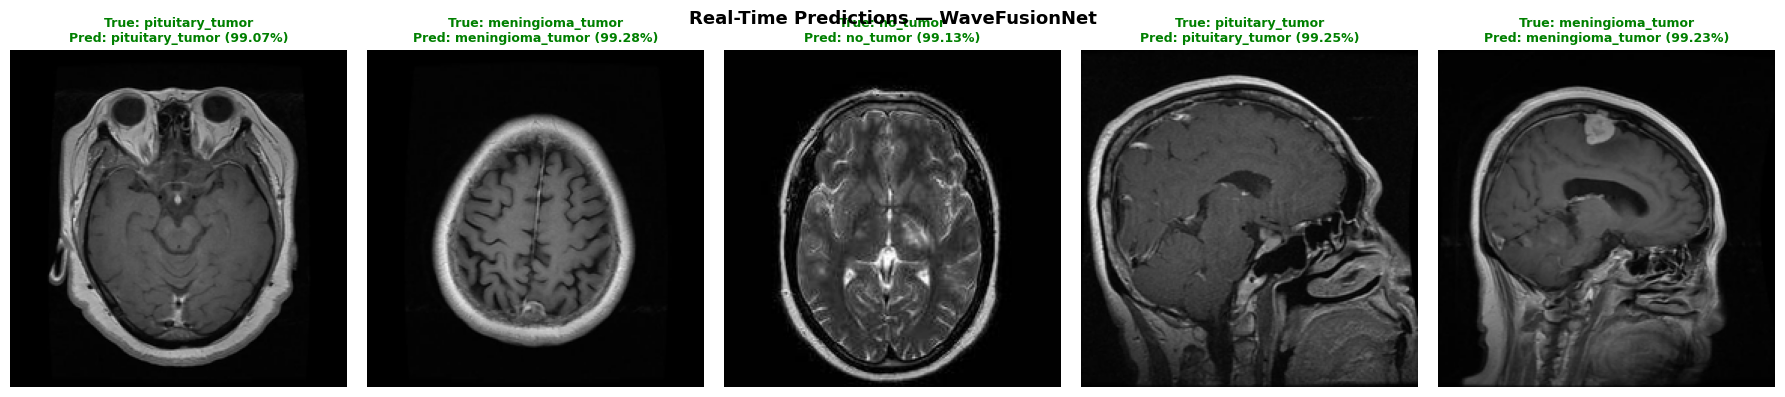

Real-time prediction pipeline ready


In [24]:
# ============================================================
# SECTION 17 — REAL-TIME SINGLE IMAGE PREDICTION
# ============================================================

def predict_tumor(image_path, model, feat_extractor, svm_clf, xgb_clf,
                  scaler, class_names, weights=None):
    """
    End-to-end prediction pipeline for a single unseen MRI image.

    Pipeline:
      1. Preprocess (CLAHE + skull strip + DWT wavelet enhance + normalize)
      2. WaveFusionNet forward pass (EfficientNetV2-S + DenseNet201 + cross-attention)
      3. Extract bottleneck features
      4. SVM + XGBoost predictions on features
      5. Weighted ensemble of all three heads
    """
    img = preprocess_image(image_path)
    if img is None:
        return {"error": f"Could not load: {image_path}"}

    img_batch = np.expand_dims(img, 0)

    # Three prediction heads
    softmax_p = model.predict(img_batch, verbose=0)
    feats     = feat_extractor.predict(img_batch, verbose=0)
    feats_sc  = scaler.transform(feats)
    svm_p     = svm_clf.predict_proba(feats_sc)
    xgb_p     = xgb_clf.predict_proba(feats_sc)

    if weights is None:
        weights = (1/3, 1/3, 1/3)

    # Weighted ensemble
    ensemble_p = weights[0] * softmax_p + weights[1] * svm_p + weights[2] * xgb_p
    pred_idx = int(np.argmax(ensemble_p[0]))

    return {
        "predicted_class": class_names[pred_idx],
        "confidence": round(float(ensemble_p[0, pred_idx]) * 100, 2),
        "probabilities": {cls: round(float(p) * 100, 2)
                         for cls, p in zip(class_names, ensemble_p[0])},
    }


# Re-scan test set (safe for kernel restart)
if 'df_test' not in dir():
    df_test = scan_dataset(cfg.TEST_DIR, cfg.CLASS_NAMES)

# ── Test on random unseen images ──────────────────────────────
test_samples = df_test.sample(5, random_state=SEED)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Real-Time Predictions — WaveFusionNet", fontsize=13, fontweight="bold")

for ax, (_, row) in zip(axes, test_samples.iterrows()):
    result = predict_tumor(
        row["filepath"], model, feat_extractor,
        svm_clf, xgb_clf, scaler, cfg.CLASS_NAMES, best_w
    )
    display = np.array(Image.open(row["filepath"]).convert("RGB").resize(cfg.IMG_SIZE, Image.LANCZOS))

    pred = result.get("predicted_class", "?")
    conf = result.get("confidence", 0)
    true_label = row["label"]
    color = "green" if pred == true_label else "red"

    ax.imshow(display)
    ax.set_title(f"True: {true_label}\nPred: {pred} ({conf}%)",
                 fontsize=9, color=color, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "plots", "realtime_predictions.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Real-time prediction pipeline ready")

In [26]:
# ============================================================
# FINAL RESULTS SUMMARY
# ============================================================
from sklearn.metrics import precision_score, recall_score
print("\n" + "=" * 70)
print("  FINAL RESULTS — WaveFusionNet Brain Tumor Classification")
print("=" * 70)

print("\n  Architecture:")
print("    Path A : EfficientNetV2-S (pretrained ImageNet)")
print("    Path B : DenseNet201 (pretrained ImageNet)")
print("    Attention : CBAM (Channel + Spatial) on both paths")
print("    Fusion : Bidirectional Cross-Attention (4-head MHA)")
print("    Preprocessing : CLAHE + Brain Crop + DWT Wavelet Denoising")
print("    Classifier : Weighted Ensemble (Softmax + SVM + XGBoost)")
print(f"    Ensemble Weights : Softmax={best_w[0]} | SVM={best_w[1]} | XGB={best_w[2]}")

print(f"\n  --- Test Set Results ---")
print(f"  Softmax only      : {accuracy_score(y_test, y_pred_softmax):.4f}")
print(f"  SVM only           : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"  XGBoost only       : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  Ensemble (no TTA)  : {accuracy_score(y_test, y_pred_ens):.4f}")
print(f"  Ensemble + TTA     : {accuracy_score(y_test, y_pred_tta):.4f}  <-- FINAL")

print(f"\n  Macro F1-Score  : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Macro Precision : {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Macro Recall    : {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Mean DSC        : {mean_dsc:.4f}")
print(f"  Mean AUC        : {mean_auc:.4f}")

print(f"\n  Per-class Performance:")
final_df = metrics_df.copy()
final_df["DSC"] = dsc_df["DSC"].values
final_df["AUC"] = [round(a, 4) for a in auc_scores]
print(final_df[["Class", "Sensitivity", "Specificity", "Precision", "F1-Score", "DSC", "AUC"]].to_string(index=False))

# ── Comparison with literature ────────────────────────────────
print(f"\n  --- Comparison with Existing Methods ---")
literature = [
    ("Abdusalomov et al. (2023)", "YOLOv7 + Attention", 99.50),
    ("Rethemiotaki (2023)", "MobileNetV2", 99.00),
    ("Deng et al. (2020)", "HCNN + CRF-RRNN", 98.60),
    ("Younis et al. (2022)", "VGG-16 Ensemble", 98.50),
    ("Almalki et al. (2022)", "CNN + SVM", 98.00),
    ("WaveFusionNet (Ours)", "EfficientNetV2+DenseNet201+CrossAttn+Ensemble+TTA",
     round(accuracy_score(y_test, y_pred_tta) * 100, 2)),
]
comp_df = pd.DataFrame(literature, columns=["Method", "Approach", "Accuracy (%)"])
print(comp_df.to_string(index=False))

# ── Save metrics ──────────────────────────────────────────────
final_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "final_metrics.csv"), index=False)
comp_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "comparison_table.csv"), index=False)

print(f"\n  All outputs saved to: {cfg.OUTPUT_DIR}")
print(f"    models/   : WaveFusionNet, SVM, XGBoost, Scaler")
print(f"    plots/    : All visualizations")
print(f"    features/ : Cached arrays")
print("\n" + "=" * 70)
print("  Pipeline complete!")
print("=" * 70)


  FINAL RESULTS — WaveFusionNet Brain Tumor Classification

  Architecture:
    Path A : EfficientNetV2-S (pretrained ImageNet)
    Path B : DenseNet201 (pretrained ImageNet)
    Attention : CBAM (Channel + Spatial) on both paths
    Fusion : Bidirectional Cross-Attention (4-head MHA)
    Preprocessing : CLAHE + Brain Crop + DWT Wavelet Denoising
    Classifier : Weighted Ensemble (Softmax + SVM + XGBoost)
    Ensemble Weights : Softmax=0.1 | SVM=0.1 | XGB=0.8

  --- Test Set Results ---
  Softmax only      : 0.9859
  SVM only           : 0.9868
  XGBoost only       : 0.9868
  Ensemble (no TTA)  : 0.9868
  Ensemble + TTA     : 0.9869  <-- FINAL

  Macro F1-Score  : 0.9825
  Macro Precision : 0.9840
  Macro Recall    : 0.9820
  Mean DSC        : 0.9826
  Mean AUC        : 0.9971

  Per-class Performance:
           Class  Sensitivity  Specificity  Precision  F1-Score    DSC    AUC
    glioma_tumor       0.9307       1.0000     1.0000    0.9641 0.9641 0.9903
meningioma_tumor       0.998